In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
pd.set_option('display.max_rows', 12000)


### Functions needed in preprocessing

In [2]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    percent = (len(outliers) / len(df)) * 100
    print(f"precentage of outliers in column {column} is {percent:.2f}%")

In [3]:
def cal_col(data):
    num_col = data.select_dtypes(include=['float64','int64']).columns
    col = data.columns
    return col,num_col

In [4]:
def cal_corr(num_col,data,ann = True):
    corr = data[num_col].corr()
    sns.heatmap(data = corr, annot = ann)
    plt.show()

In [5]:
def dropping_col_based_on_nulls_precentage(data):
    threshold = data.shape[0] * 0.5
    col_to_drop = data.columns[data.isna().sum() >= threshold]
    data.drop(col_to_drop, inplace = True,axis = 1)
    return data

In [6]:
def season(hemi,daymonth):
    """Northern Hemisphere:
Spring: March 20 (around the Spring Equinox)
Summer: June 21 (around the Summer Solstice)
Fall (Autumn): September 23 (around the Fall Equinox)
Winter: December 21 (around the Winter Solstice)
Southern Hemisphere:
Spring: September 23 (around the Spring Equinox)
Summer: December 21 (around the Summer Solstice)
Fall (Autumn): March 20 (around the Fall Equinox)
Winter: June 21 (around the Winter Solstice). 
"""

   
    st_r1 = datetime.strptime('2020-03-20', '%Y-%m-%d')
    st_r2 = datetime.strptime('2020-06-21', '%Y-%m-%d')
    st_r3 = datetime.strptime('2019-09-23', '%Y-%m-%d')
    st_r4 = datetime.strptime('2019-12-21', '%Y-%m-%d')

    if hemi == 'Northern':
      if st_r1 <= daymonth < st_r2:
         return "Spring"
      elif st_r2 <= daymonth < st_r3:
         return "Summer"
      elif st_r3 <= daymonth < st_r4:
         return "Fall"
      else:
         return "Winter"
    else:
        if st_r1 <= daymonth < st_r2:
         return "Fall"
        elif st_r2 <= daymonth < st_r3:
         return "Winter"
        elif st_r3 <= daymonth < st_r4:
         return "Spring"
        else:
         return "Summer"

In [7]:
def convert_hemisphere_season(df,col):
    categ =[ 'Winter', 'Spring', 'Summer', 'Fall']
    
    g = df.groupby(['Hemisphere','Season'])[col].sum().reset_index()
    # to it knows that is has specific order not use it as string when sorting
    g['Season'] = pd.Categorical(g['Season'],categ)
    # sorting
    g.sort_values('Season')
    
    plt.figure(figsize=(8,6))
    sns.lineplot(data=g,x='Season',y=col,hue='Hemisphere')
    plt.title(f'{col} cases by Season')

### reading files

In [8]:
country_wise_df = pd.read_csv('country_wise_latest.csv')
covid_19_clean_complete_df = pd.read_csv("covid_19_clean_complete.csv")
full_grouped_df = pd.read_csv('full_grouped.csv')
day_wise_df = pd.read_csv('day_wise.csv')
usa_county_wise_df = pd.read_csv('usa_county_wise.csv')
worldometer_data_df = pd.read_csv('worldometer_data.csv')

### Our target is to get confirmed cases over datasets

### Working with country_wise dataset

In [9]:
country_wise_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [10]:
col,num_col = cal_col(country_wise_df)

In [11]:
country_wise_df.head(20)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa
5,Antigua and Barbuda,86,3,65,18,4,0,5,3.49,75.58,4.62,76,10,13.16,Americas
6,Argentina,167416,3059,72575,91782,4890,120,2057,1.83,43.35,4.21,130774,36642,28.02,Americas
7,Armenia,37390,711,26665,10014,73,6,187,1.90,71.32,2.67,34981,2409,6.89,Europe
8,Australia,15303,167,9311,5825,368,6,137,1.09,60.84,1.79,12428,2875,23.13,Western Pacific
9,Austria,20558,713,18246,1599,86,1,37,3.47,88.75,3.91,19743,815,4.13,Europe


In [12]:
country_wise_df.describe()

c:\Users\sondo\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


from previous statistics measurements we will find out that there are outliers in most of these columns
let's start with ploting them
then calculating the IQR and apply Winsorizing

#### handling Outliers

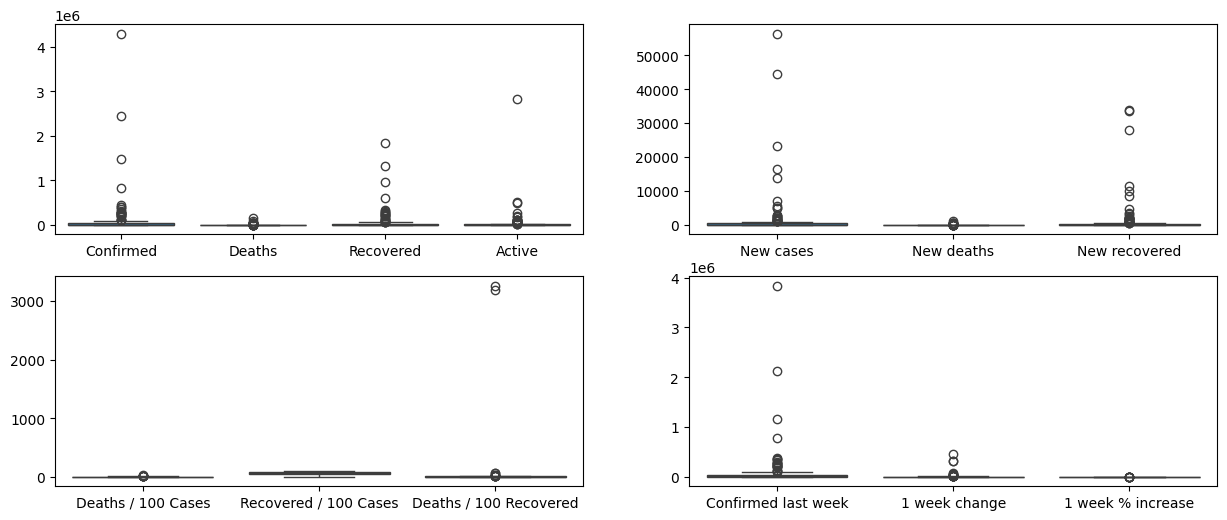

In [13]:
plt.figure(figsize=(15, 6))
plt.subplot(2,2,1)
sns.boxplot(data= country_wise_df[num_col[:4]])

plt.subplot(2,2,2)
sns.boxplot(data= country_wise_df[num_col[4:7]])

plt.subplot(2,2,3)
sns.boxplot(data= country_wise_df[num_col[7:10]])

plt.subplot(2,2,4)
sns.boxplot(data= country_wise_df[num_col[10:]])
plt.show()

In [14]:
for i in num_col:
   cap_outliers(country_wise_df,i)

precentage of outliers in column Confirmed is 12.83%
precentage of outliers in column Deaths is 17.65%
precentage of outliers in column Recovered is 13.37%
precentage of outliers in column Active is 17.11%
precentage of outliers in column New cases is 13.37%
precentage of outliers in column New deaths is 14.97%
precentage of outliers in column New recovered is 16.58%
precentage of outliers in column Deaths / 100 Cases is 5.35%
precentage of outliers in column Recovered / 100 Cases is 0.00%
precentage of outliers in column Deaths / 100 Recovered is 9.63%
precentage of outliers in column Confirmed last week is 12.30%
precentage of outliers in column 1 week change is 11.76%
precentage of outliers in column 1 week % increase is 4.28%


* Based on the previous calculations we will found that most of the columns have outliers which are greater than 5% then we can't replace or clip

In [15]:
country_wise_df.drop_duplicates(keep = 'first',inplace = True)
country_wise_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

#### Getting relations using correlation

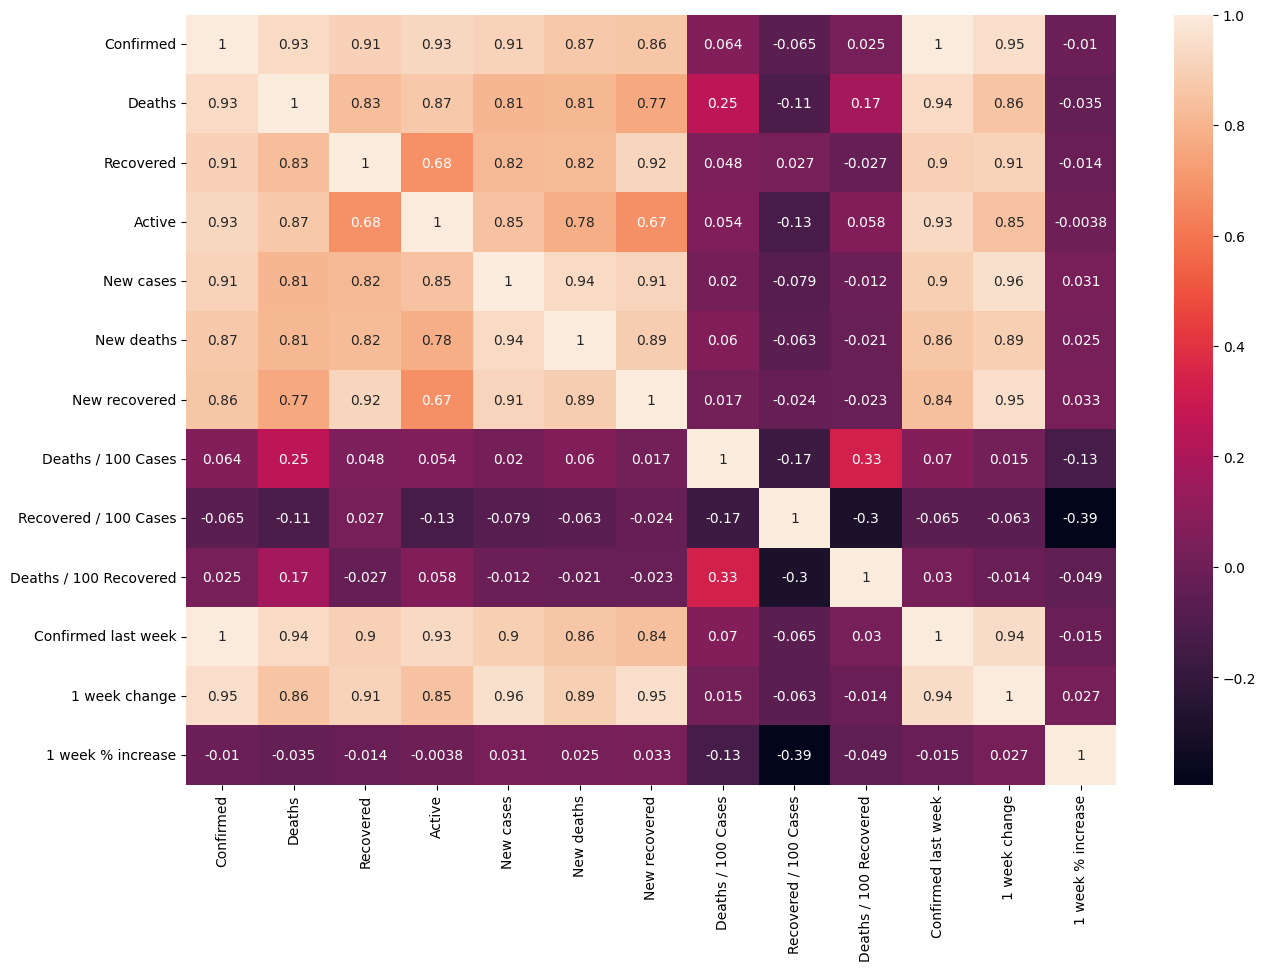

In [16]:
plt.figure(figsize=(15, 10))
cal_corr(num_col,country_wise_df)

In [17]:
col_to_remove_ind = [num_col[-1],num_col[-4],num_col[-5],num_col[-6]]
country_wise_df = country_wise_df.drop(col_to_remove_ind, axis=1)

In [18]:
max_countries_in_active_in_each_who_region = country_wise_df.groupby('WHO Region')['Country/Region'].agg({max_death := ('Deaths',"max"), max_confirmed := ('Confirmed','max'),max_recovered := ('Recovered','max')})
max_countries_in_active_in_each_who_region

,Confirmed,Recovered,Deaths
WHO Region,,,
Africa,Zimbabwe,Zimbabwe,Zimbabwe
Americas,Venezuela,Venezuela,Venezuela
Eastern Mediterranean,Yemen,Yemen,Yemen
Europe,Uzbekistan,Uzbekistan,Uzbekistan
South-East Asia,Timor-Leste,Timor-Leste,Timor-Leste
Western Pacific,Vietnam,Vietnam,Vietnam


In [19]:
max_countries_in_active_in_each_who_region_per = country_wise_df.groupby('WHO Region')['Country/Region'].agg({max_death_100_cases := ('Deaths / 100 Cases country',"max"), max_recover_100_cases := ('Recovered / 100 Cases country','max'),max_death_for_100_recover := ('Deaths / 100 Recovered country','max')})
max_countries_in_active_in_each_who_region_per

,Deaths / 100 Recovered country,Deaths / 100 Cases country,Recovered / 100 Cases country
WHO Region,,,
Africa,Zimbabwe,Zimbabwe,Zimbabwe
Americas,Venezuela,Venezuela,Venezuela
Eastern Mediterranean,Yemen,Yemen,Yemen
Europe,Uzbekistan,Uzbekistan,Uzbekistan
South-East Asia,Timor-Leste,Timor-Leste,Timor-Leste
Western Pacific,Vietnam,Vietnam,Vietnam


In [20]:
col,num_col = cal_col(country_wise_df)

In [21]:
country_wise_df[num_col].describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Confirmed last week,1 week change
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,1.870000e+02,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,7.868248e+04,9448.459893
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.382737e+05,47491.127684
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+01,-47.000000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,1.051500e+03,49.000000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,5.020000e+03,432.000000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.708050e+04,3172.000000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,3.834677e+06,455582.000000


In [22]:
who_reg_val = country_wise_df['WHO Region'].unique()
who_reg_val

array(['Eastern Mediterranean', 'Europe', 'Africa', 'Americas',
       'Western Pacific', 'South-East Asia'], dtype=object)

#### Plotting

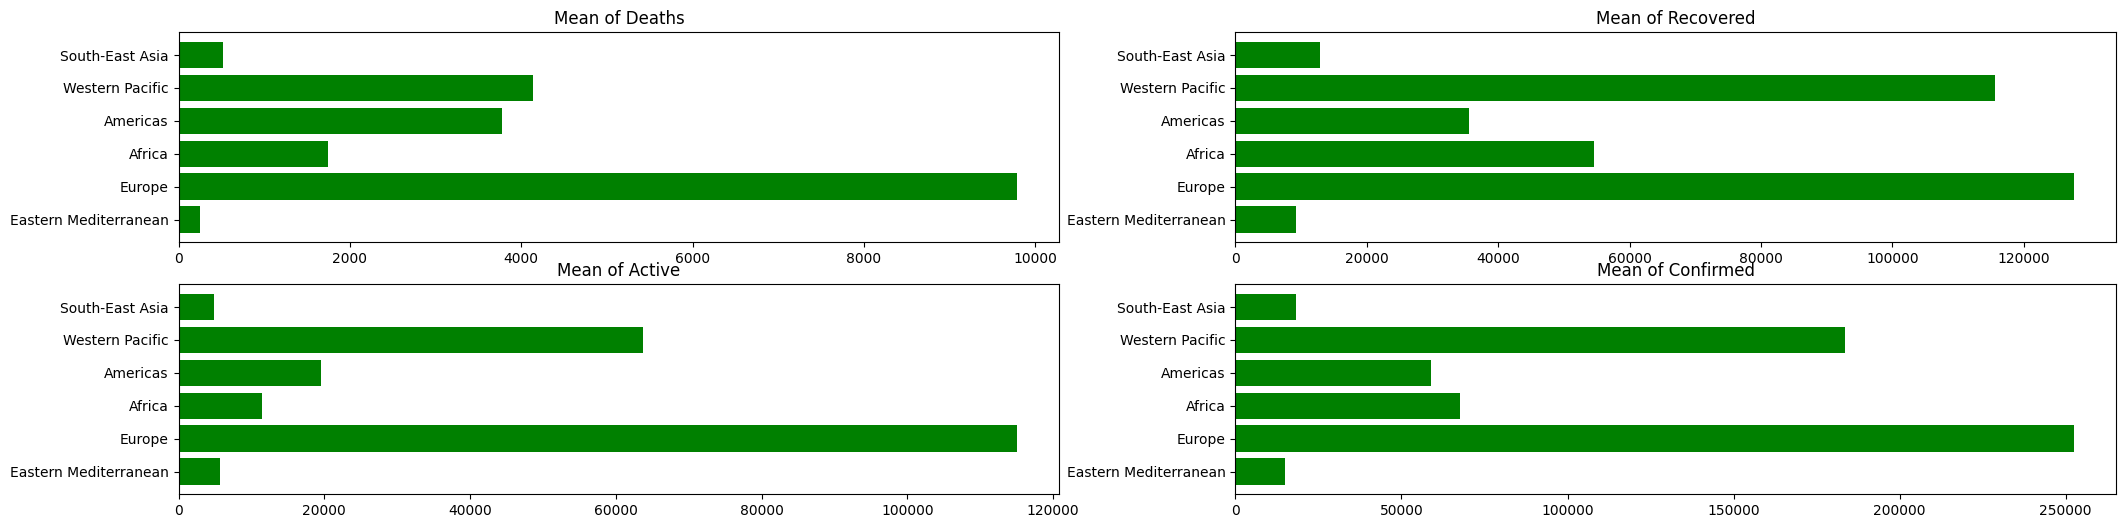

In [23]:
plt.figure(figsize=(25, 6))
plt.subplot(2,2,1)
plt.barh(who_reg_val,country_wise_df.groupby('WHO Region')['Deaths'].mean(),color = 'green')
plt.title('Mean of Deaths')

plt.subplot(2,2,2)
plt.barh(who_reg_val,country_wise_df.groupby('WHO Region')['Recovered'].mean(),color = 'green')
plt.title('Mean of Recovered')

plt.subplot(2,2,3)
plt.barh(who_reg_val,country_wise_df.groupby('WHO Region')['Active'].mean(),color = 'green')
plt.title('Mean of Active')

plt.subplot(2,2,4)
plt.barh(who_reg_val,country_wise_df.groupby('WHO Region')['Confirmed'].mean(),color = 'green')
plt.title('Mean of Confirmed')

plt.show()

In [24]:
countries = list(x for x in max_countries_in_active_in_each_who_region["Recovered"])
countries

['Zimbabwe', 'Venezuela', 'Yemen', 'Uzbekistan', 'Timor-Leste', 'Vietnam']

In [25]:
y = country_wise_df[ country_wise_df['Country/Region'].isin(countries)]

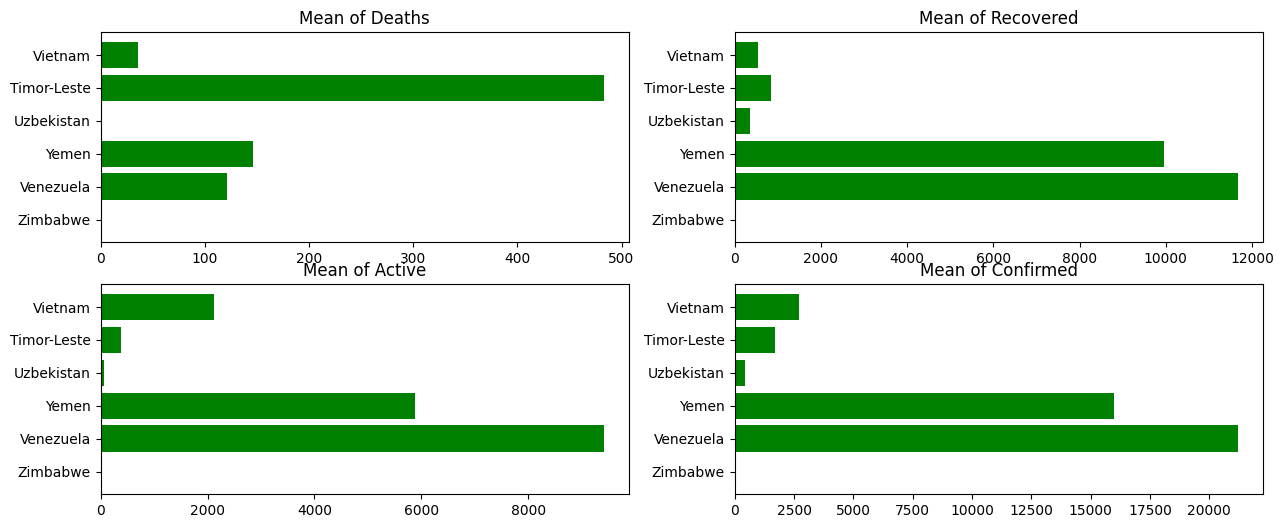

In [26]:
plt.figure(figsize=(15, 6))

plt.subplot(2,2,1)
plt.barh(countries, y['Deaths'],color = 'green')
plt.title('Mean of Deaths')

plt.subplot(2,2,2)
plt.barh(countries, y['Recovered'],color = 'green')
plt.title('Mean of Recovered')

plt.subplot(2,2,3)
plt.barh(countries, y['Active'],color = 'green')
plt.title('Mean of Active')

plt.subplot(2,2,4)
plt.barh(countries, y['Confirmed'],color = 'green')
plt.title('Mean of Confirmed')

plt.show()

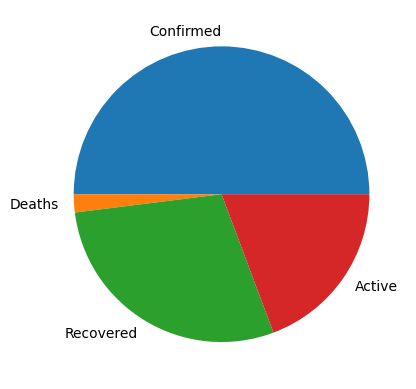

In [27]:
plt.pie(country_wise_df[num_col[:4]].sum(),labels = num_col[:4])
plt.show()

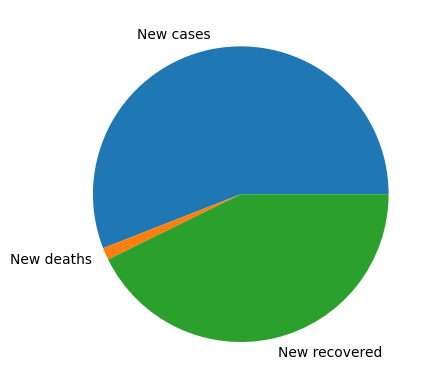

In [28]:
plt.pie(country_wise_df[num_col[4:7]].sum(),labels = num_col[4:7])
plt.show()

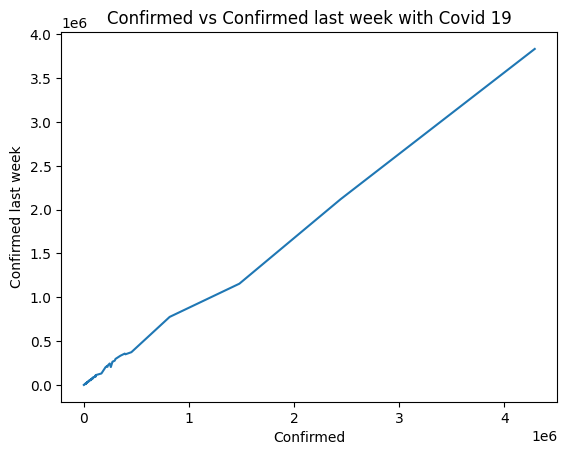

In [29]:
sns.lineplot(x='Confirmed', y='Confirmed last week', data=country_wise_df)
plt.title("Confirmed vs Confirmed last week with Covid 19")
plt.show()

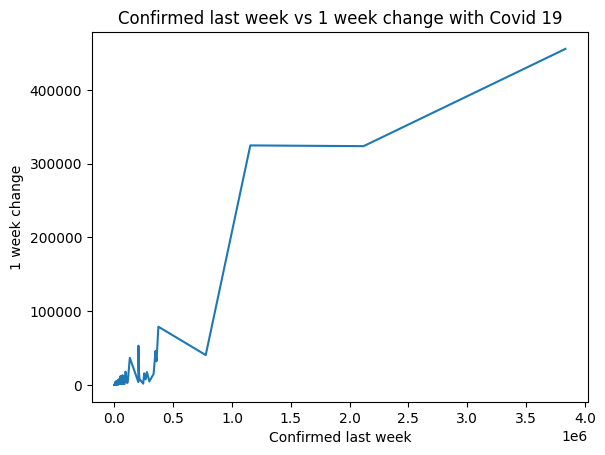

In [30]:
sns.lineplot(x='Confirmed last week', y='1 week change', data=country_wise_df)
plt.title("Confirmed last week vs 1 week change with Covid 19")
plt.show()

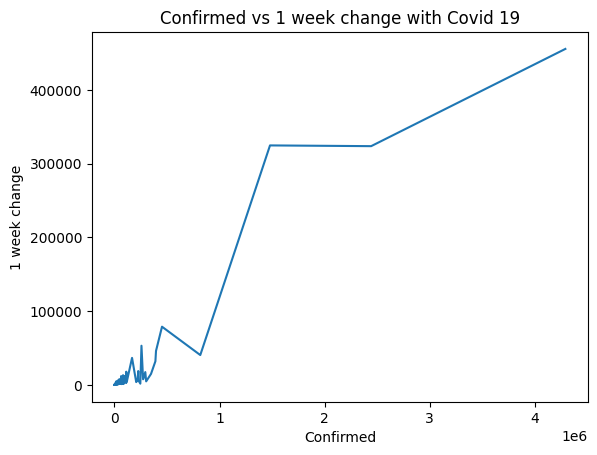

In [31]:
sns.lineplot(x='Confirmed', y='1 week change', data=country_wise_df)
plt.title("Confirmed vs 1 week change with Covid 19")
plt.show()

In [32]:
d1 = country_wise_df
d1.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Confirmed last week',
       '1 week change', 'WHO Region'],
      dtype='object')

#### Analysis Results:
* The highest WHO Region in
    * 'Total cases' of Covid 19
        1. Africa
        2. Europe
    * 'Total active'
        1. Europe
        2. Africa
    * 'Total recovered'
        1. Europe
        2. Western Pacific
    * 'Total deaths'
        1. Europe
        2. Americans
*  For each WHO region has x countries and for the maximum value in each one:
    * for total recovered column
        1. Venezuela
        2. Yemen
    * for total cases column
        1. Venezuela
        2. Yemen
    * for Total deaths column
        1. Timor-Leste
        2. Yemen
    * for active column
        1. Venezuela
        2. Yemen
* Over weeks the number of confirmed cases are increasing
* Deaths has the lowest precentage over the different cases
* Recovered cases have the second highest percentage over time
* Columns that high correlated with Confirmed column are (Country/Region, Confirmed, Deaths, Recovered, Active, New cases, New deaths, New recovered, Confirmed last week, 1 week change, WHO Region, Total cases, Total deaths, Total recovered, Total active)

### Working with covid_19_clean_complete dataset

In [33]:
covid_19_clean_complete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [34]:
covid_19_clean_complete_df=dropping_col_based_on_nulls_precentage(covid_19_clean_complete_df)

In [35]:
col,num_col = cal_col(covid_19_clean_complete_df)

In [36]:
covid_19_clean_complete_df.head()

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [37]:
covid_19_clean_complete_df.tail()

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
49063,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe
49067,Lesotho,-29.610000,28.233600,2020-07-27,505,12,128,365,Africa


In [38]:
covid_19_clean_complete_df['Date'] = pd.to_datetime(covid_19_clean_complete_df['Date'])

In [39]:
country = covid_19_clean_complete_df['Country/Region'].unique()
country

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Benin', 'Bhutan', 'Bolivia',
       'Bosnia and Herzegovina', 'Brazil', 'Brunei', 'Bulgaria',
       'Burkina Faso', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Congo (Brazzaville)', 'Congo (Kinshasa)', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Greenland', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala',
       'Guinea', 'Guyana', 'Haiti', 'Holy See', 'Honduras', 'Hungary',
       'Iceland', 'India', 'Ind

In [40]:
country_rep = {
    'Holy See': "Côte d'Ivoire",
    'Burma': 'Myanmar',
    'Swaziland': 'Eswatini',
    'US': 'USA'
}
covid_19_clean_complete_df['Country/Region'] = covid_19_clean_complete_df['Country/Region'].replace(country_rep)

In [41]:
covid_19_clean_complete_df.describe()

,Lat,Long,Date,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,49068,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,2020-04-24 12:00:00,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
min,-51.796300,-135.000000,2020-01-22 00:00:00,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,2020-03-08 18:00:00,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,2020-04-24 12:00:00,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,2020-06-10 06:00:00,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,2020-07-27 00:00:00,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06
std,24.950320,70.442740,NaN,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04


In [42]:
covid_19_clean_complete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  49068 non-null  object        
 1   Lat             49068 non-null  float64       
 2   Long            49068 non-null  float64       
 3   Date            49068 non-null  datetime64[ns]
 4   Confirmed       49068 non-null  int64         
 5   Deaths          49068 non-null  int64         
 6   Recovered       49068 non-null  int64         
 7   Active          49068 non-null  int64         
 8   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 3.4+ MB


In [43]:
num_col

Index(['Lat', 'Long', 'Confirmed', 'Deaths', 'Recovered', 'Active'], dtype='object')

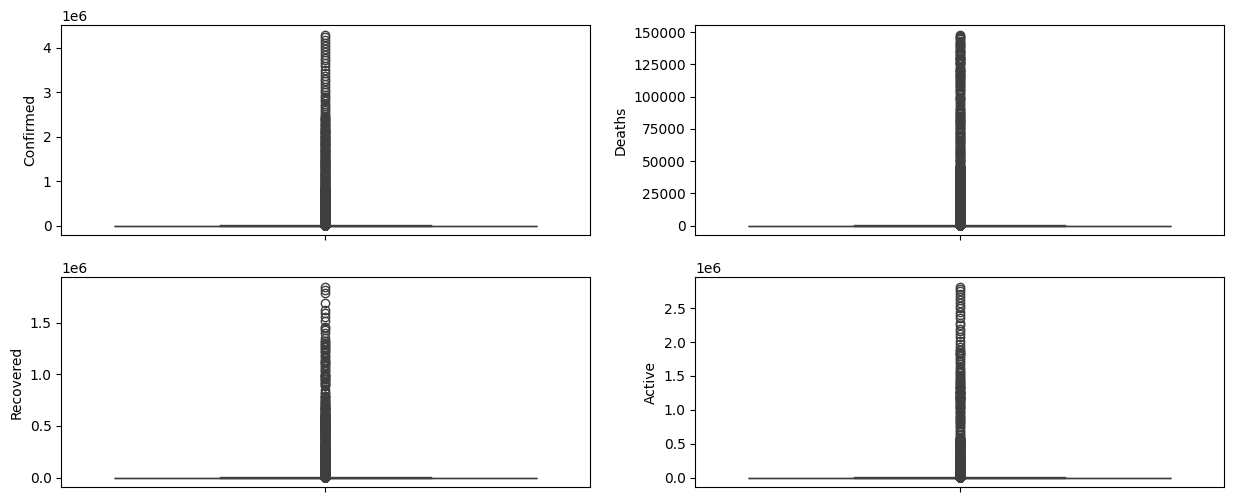

In [44]:
# Ploting before handling outliers
plt.figure(figsize=(15, 6))
plt.subplot(2,2,1)
sns.boxplot(data= covid_19_clean_complete_df[num_col[2]])

plt.subplot(2,2,2)
sns.boxplot(data= covid_19_clean_complete_df[num_col[3]])

plt.subplot(2,2,3)
sns.boxplot(data= covid_19_clean_complete_df[num_col[4]])

plt.subplot(2,2,4)
sns.boxplot(data= covid_19_clean_complete_df[num_col[5]])
plt.show()

In [45]:
for i in num_col:
    cap_outliers(covid_19_clean_complete_df,i)

precentage of outliers in column Lat is 0.77%
precentage of outliers in column Long is 0.00%
precentage of outliers in column Confirmed is 17.97%
precentage of outliers in column Deaths is 18.50%
precentage of outliers in column Recovered is 16.17%
precentage of outliers in column Active is 18.17%


In [46]:
covid_19_clean_complete_df.drop_duplicates(keep = 'first',inplace = True)
covid_19_clean_complete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  49068 non-null  object        
 1   Lat             49068 non-null  float64       
 2   Long            49068 non-null  float64       
 3   Date            49068 non-null  datetime64[ns]
 4   Confirmed       49068 non-null  int64         
 5   Deaths          49068 non-null  int64         
 6   Recovered       49068 non-null  int64         
 7   Active          49068 non-null  int64         
 8   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 3.4+ MB


### Feature Engineering

In [47]:
print(covid_19_clean_complete_df['Date'].min())
print(covid_19_clean_complete_df['Date'].max())

2020-01-22 00:00:00
2020-07-27 00:00:00


In [48]:
covid_19_clean_complete_df['Hemisphere'] = covid_19_clean_complete_df['Lat'].apply(lambda x: "Northern" if x >= 0 else "Southern")
covid_19_clean_complete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  49068 non-null  object        
 1   Lat             49068 non-null  float64       
 2   Long            49068 non-null  float64       
 3   Date            49068 non-null  datetime64[ns]
 4   Confirmed       49068 non-null  int64         
 5   Deaths          49068 non-null  int64         
 6   Recovered       49068 non-null  int64         
 7   Active          49068 non-null  int64         
 8   WHO Region      49068 non-null  object        
 9   Hemisphere      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [49]:
covid_19_clean_complete_df['Season'] = covid_19_clean_complete_df.apply(lambda x: season(x['Hemisphere'],x['Date']),axis=1)
covid_19_clean_complete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  49068 non-null  object        
 1   Lat             49068 non-null  float64       
 2   Long            49068 non-null  float64       
 3   Date            49068 non-null  datetime64[ns]
 4   Confirmed       49068 non-null  int64         
 5   Deaths          49068 non-null  int64         
 6   Recovered       49068 non-null  int64         
 7   Active          49068 non-null  int64         
 8   WHO Region      49068 non-null  object        
 9   Hemisphere      49068 non-null  object        
 10  Season          49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 4.1+ MB


In [50]:
covid_19_clean_complete_df.head()

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region,Hemisphere,Season
0,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean,Northern,Winter
1,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe,Northern,Winter
2,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa,Northern,Winter
3,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe,Northern,Winter
4,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa,Southern,Summer


In [51]:
covid_19_clean_complete_df['Season'].unique()

array(['Winter', 'Summer', 'Spring', 'Fall'], dtype=object)

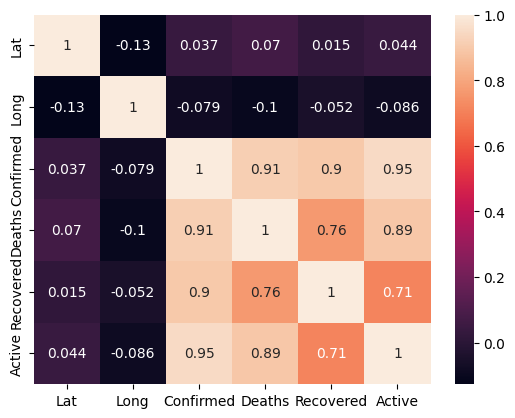

In [52]:
cal_corr(num_col,covid_19_clean_complete_df)

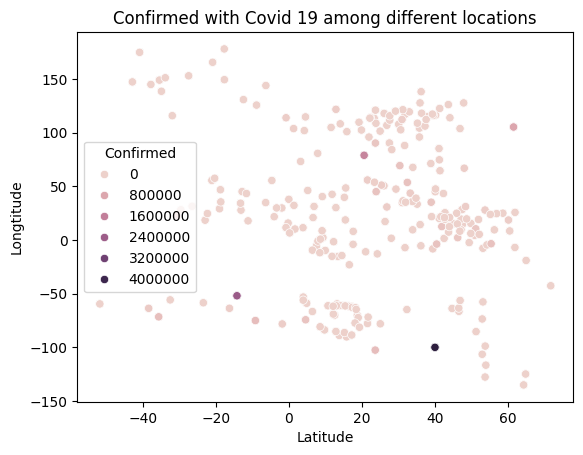

In [53]:
sns.scatterplot(x= 'Lat', y='Long',hue = 'Confirmed', data=covid_19_clean_complete_df)
plt.title("Confirmed with Covid 19 among different locations")
plt.xlabel('Latitude')
plt.ylabel('Longtitude')
plt.show()

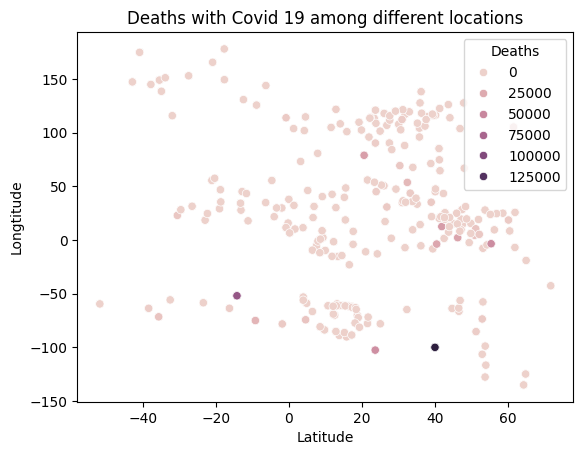

In [54]:
sns.scatterplot(x= 'Lat', y='Long',hue = 'Deaths', data=covid_19_clean_complete_df)
plt.title("Deaths with Covid 19 among different locations")
plt.xlabel('Latitude')
plt.ylabel('Longtitude')
plt.show()

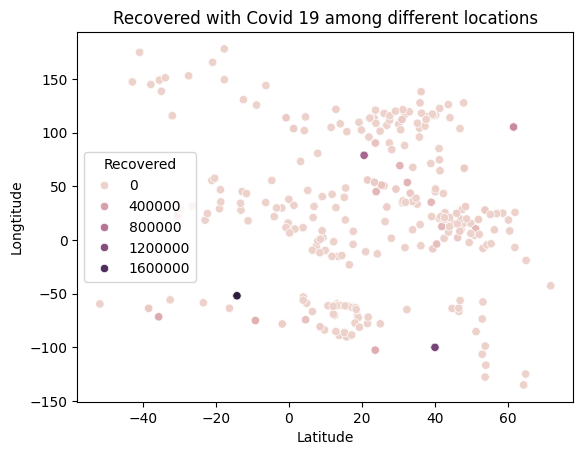

In [55]:
sns.scatterplot(x= 'Lat', y='Long',hue = 'Recovered', data=covid_19_clean_complete_df)
plt.title("Recovered with Covid 19 among different locations")
plt.xlabel('Latitude')
plt.ylabel('Longtitude')
plt.show()

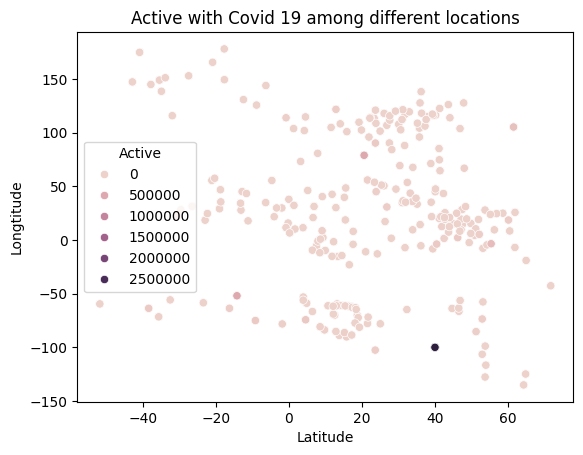

In [56]:
sns.scatterplot(x= 'Lat', y='Long',hue = 'Active', data=covid_19_clean_complete_df)
plt.title("Active with Covid 19 among different locations")
plt.xlabel('Latitude')
plt.ylabel('Longtitude')
plt.show()

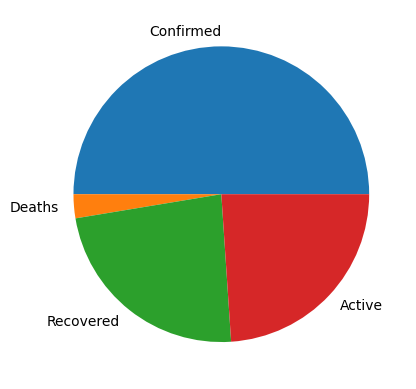

In [57]:
plt.pie(covid_19_clean_complete_df[num_col[2:]].sum(),labels = num_col[2:])
plt.show()

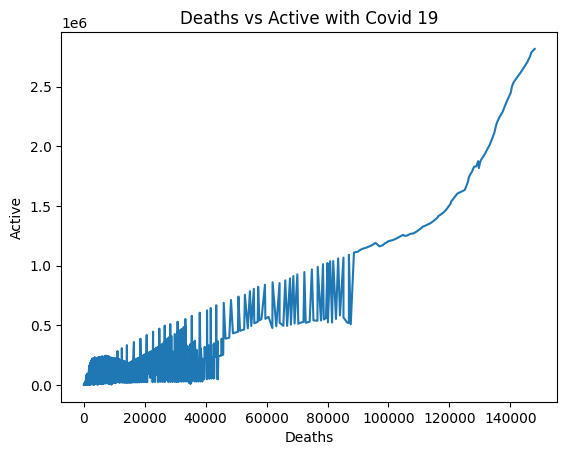

In [58]:
sns.lineplot(x='Deaths', y='Active', data=covid_19_clean_complete_df)
plt.title("Deaths vs Active with Covid 19")
plt.show()

To ensure consistent formatting and avoid plotting errors, `reset_index()` was used to organize the data clearly and uniformly.

The final format aligns each season label on a separate row, like this:

- Northern Winter  
- Northern Fall  
- Southern Winter  
- Southern Fall  

Instead of inconsistent or compressed formats like:

- map Northern Winter  
- Fall ...

This approach ensures cleaner visuals and easier interpretation during plotting.

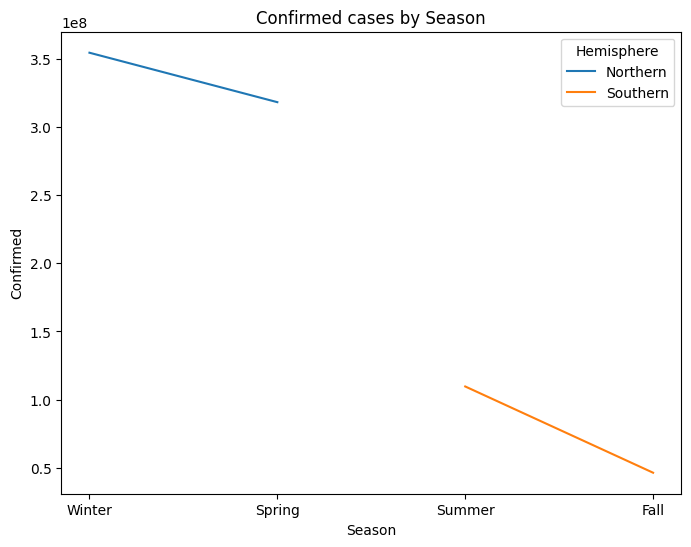

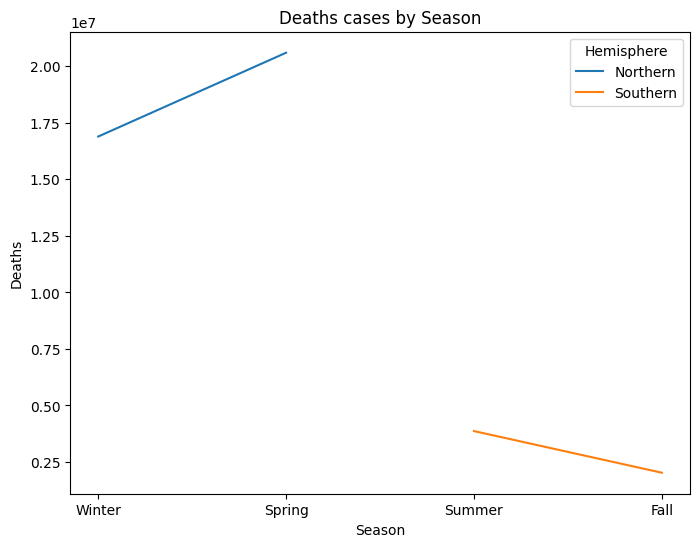

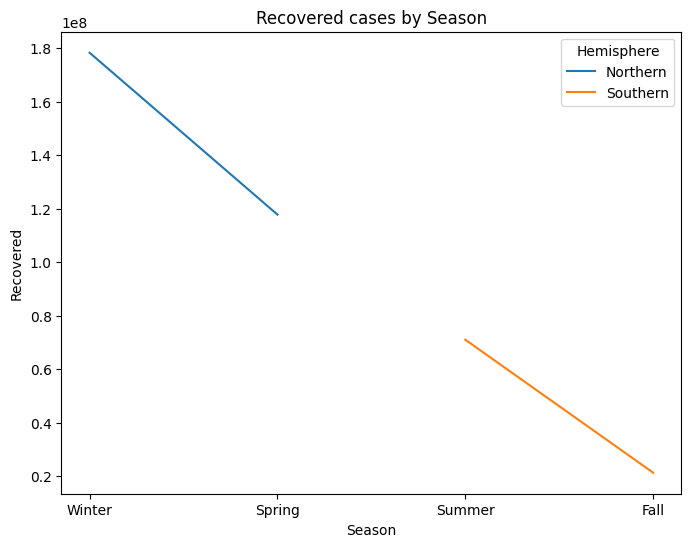

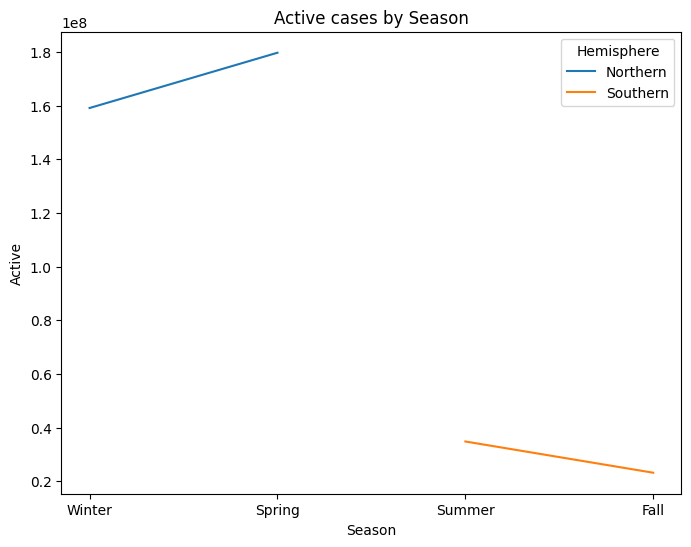

In [59]:
cases = ['Confirmed','Deaths','Recovered','Active']
for i in cases:
    convert_hemisphere_season(covid_19_clean_complete_df,i)

In [60]:
covid_19_clean_complete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  49068 non-null  object        
 1   Lat             49068 non-null  float64       
 2   Long            49068 non-null  float64       
 3   Date            49068 non-null  datetime64[ns]
 4   Confirmed       49068 non-null  int64         
 5   Deaths          49068 non-null  int64         
 6   Recovered       49068 non-null  int64         
 7   Active          49068 non-null  int64         
 8   WHO Region      49068 non-null  object        
 9   Hemisphere      49068 non-null  object        
 10  Season          49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 4.1+ MB


In [61]:
col,num_col = cal_col(covid_19_clean_complete_df)
print(col)
print(num_col)

Index(['Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths',
       'Recovered', 'Active', 'WHO Region', 'Hemisphere', 'Season'],
      dtype='object')
Index(['Lat', 'Long', 'Confirmed', 'Deaths', 'Recovered', 'Active'], dtype='object')


In [62]:
col_to_remove_ind = [col[1],col[2],col[3]]
d2 = covid_19_clean_complete_df.drop(col_to_remove_ind, axis=1)

In [63]:
d2.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'WHO Region', 'Hemisphere', 'Season'],
      dtype='object')

#### Analysis

- There is a clear seasonal variation in COVID-19 cases, with higher incident rates during colder months (Winter and Spring) and a decline during Summer and Fall.
- The Northern Hemisphere generally experiences higher case and death counts compared to the Southern Hemisphere, consistent with the earlier analysis.
- The trends in recovered, active, deaths, and confirmed cases reinforce the importance of seasonal and hemispheric differences in the spread and impact of COVID-19.

- The dramatic decline in recovered cases in Fall suggests potential underreporting or challenges in healthcare systems during that season.
- The consistent decrease in active cases and confirmed cases during Summer and Fall highlights the potential effectiveness of interventions or seasonal effects reducing transmission.

---

**Note:** As previously identified, latitude and longitude do not exhibit high correlations with COVID-19 case numbers, and therefore, they have been removed from further analysis to improve model efficiency.

### Working with day_wise dataset

In [64]:
col,num_col = cal_col(day_wise_df)

In [65]:
day_wise_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    188 non-null    object 
 1   Confirmed               188 non-null    int64  
 2   Deaths                  188 non-null    int64  
 3   Recovered               188 non-null    int64  
 4   Active                  188 non-null    int64  
 5   New cases               188 non-null    int64  
 6   New deaths              188 non-null    int64  
 7   New recovered           188 non-null    int64  
 8   Deaths / 100 Cases      188 non-null    float64
 9   Recovered / 100 Cases   188 non-null    float64
 10  Deaths / 100 Recovered  188 non-null    float64
 11  No. of countries        188 non-null    int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 17.8+ KB


In [66]:
day_wise_df['Date'] = pd.to_datetime(day_wise_df['Date'])

In [67]:
day_wise_df.head()

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries
0,2020-01-22,555,17,28,510,0,0,0,3.06,5.05,60.71,6
1,2020-01-23,654,18,30,606,99,1,2,2.75,4.59,60.00,8
2,2020-01-24,941,26,36,879,287,8,6,2.76,3.83,72.22,9
3,2020-01-25,1434,42,39,1353,493,16,3,2.93,2.72,107.69,11
4,2020-01-26,2118,56,52,2010,684,14,13,2.64,2.46,107.69,13


In [68]:
day_wise_df['Date'].min()

Timestamp('2020-01-22 00:00:00')

In [69]:
day_wise_df['Date'].max()

Timestamp('2020-07-27 00:00:00')

In [70]:
day_wise_df[num_col].describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries
count,1.880000e+02,188.000000,1.880000e+02,1.880000e+02,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,4.406960e+06,230770.760638,2.066001e+06,2.110188e+06,87771.021277,3478.824468,50362.015957,4.860638,34.343936,22.104521,144.351064
std,4.757988e+06,217929.094183,2.627976e+06,1.969670e+06,75295.293255,2537.735652,56090.892479,1.579541,16.206159,22.568307,65.175979
min,5.550000e+02,17.000000,2.800000e+01,5.100000e+02,0.000000,0.000000,0.000000,2.040000,1.710000,6.260000,6.000000
25%,1.121910e+05,3935.000000,6.044125e+04,5.864175e+04,5568.500000,250.750000,2488.250000,3.510000,22.785000,9.650000,101.250000
50%,2.848733e+06,204190.000000,7.847840e+05,1.859759e+06,81114.000000,4116.000000,30991.500000,4.850000,35.680000,15.380000,184.000000
75%,7.422046e+06,418634.500000,3.416396e+06,3.587015e+06,131502.500000,5346.000000,79706.250000,6.297500,48.945000,25.342500,187.000000
max,1.648048e+07,654036.000000,9.468087e+06,6.358362e+06,282756.000000,9966.000000,284394.000000,7.180000,57.450000,134.430000,187.000000


#### Handling Outliers

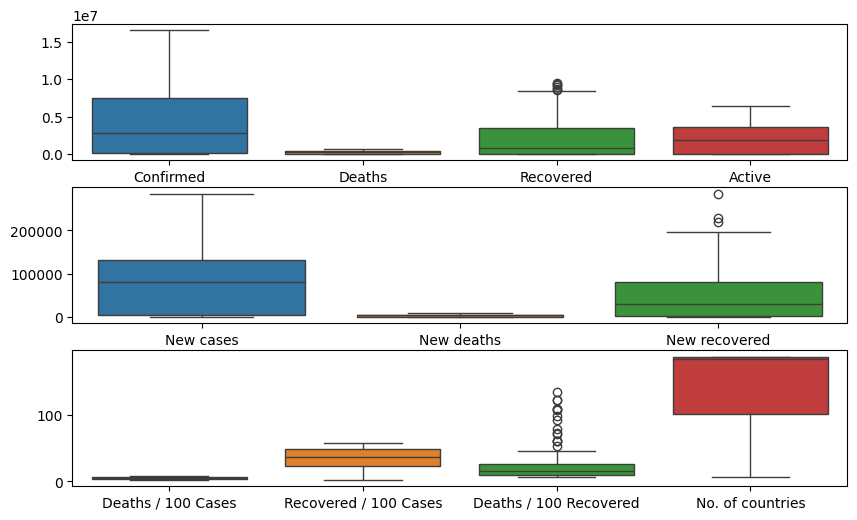

In [71]:
plt.figure(figsize=(10, 6))
plt.subplot(3,1,1)
sns.boxplot(data= day_wise_df[num_col[:4]])

plt.subplot(3,1,2)
sns.boxplot(data= day_wise_df[num_col[4:7]])

plt.subplot(3,1,3)
sns.boxplot(data= day_wise_df[num_col[7:]])

plt.show()

In [72]:
for i in num_col:
    cap_outliers(day_wise_df,i)

precentage of outliers in column Confirmed is 0.00%
precentage of outliers in column Deaths is 0.00%
precentage of outliers in column Recovered is 3.19%
precentage of outliers in column Active is 0.00%
precentage of outliers in column New cases is 0.00%
precentage of outliers in column New deaths is 0.00%
precentage of outliers in column New recovered is 1.60%
precentage of outliers in column Deaths / 100 Cases is 0.00%
precentage of outliers in column Recovered / 100 Cases is 0.00%
precentage of outliers in column Deaths / 100 Recovered is 7.98%
precentage of outliers in column No. of countries is 0.00%


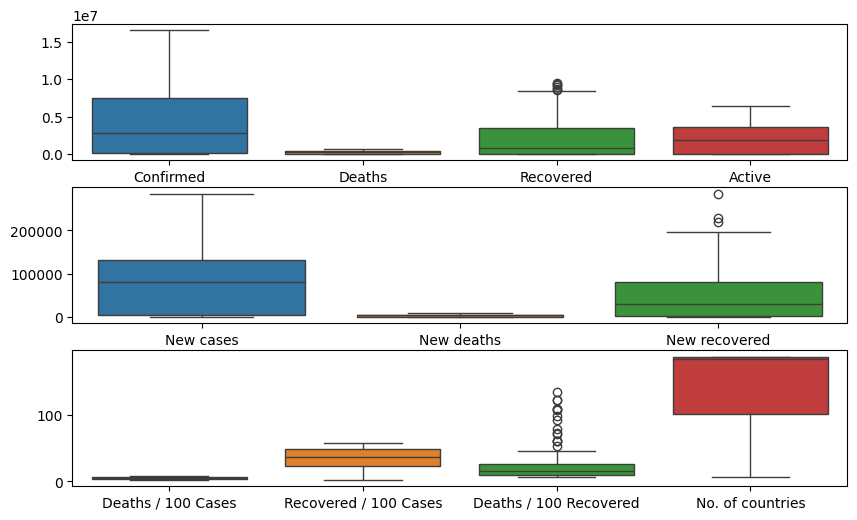

In [73]:
plt.figure(figsize=(10, 6))
plt.subplot(3,1,1)
sns.boxplot(data= day_wise_df[num_col[:4]])

plt.subplot(3,1,2)
sns.boxplot(data= day_wise_df[num_col[4:7]])

plt.subplot(3,1,3)
sns.boxplot(data= day_wise_df[num_col[7:]])

plt.show()

In [74]:
day_wise_df.drop_duplicates(keep = 'first',inplace = True)
day_wise_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    188 non-null    datetime64[ns]
 1   Confirmed               188 non-null    int64         
 2   Deaths                  188 non-null    int64         
 3   Recovered               188 non-null    int64         
 4   Active                  188 non-null    int64         
 5   New cases               188 non-null    int64         
 6   New deaths              188 non-null    int64         
 7   New recovered           188 non-null    int64         
 8   Deaths / 100 Cases      188 non-null    float64       
 9   Recovered / 100 Cases   188 non-null    float64       
 10  Deaths / 100 Recovered  188 non-null    float64       
 11  No. of countries        188 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory 

#### PLotting

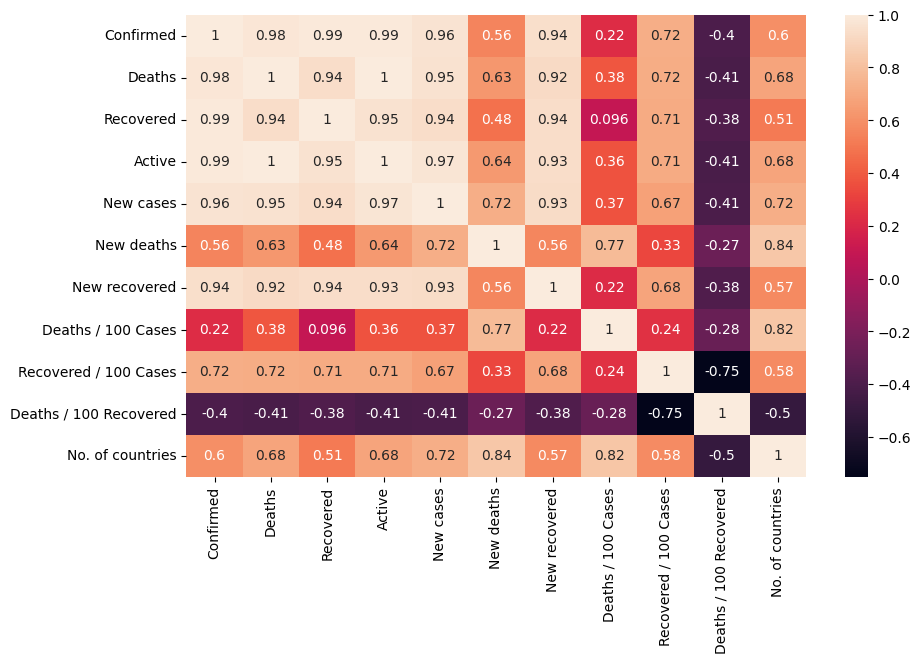

In [75]:
plt.figure(figsize=(10, 6))
cal_corr(num_col,day_wise_df)

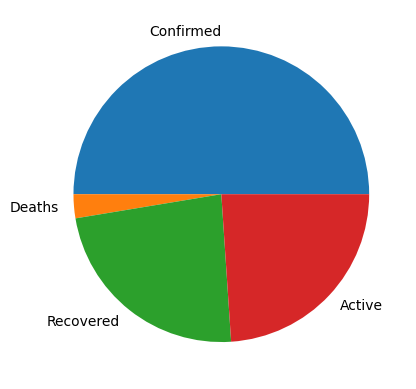

In [76]:
plt.pie(day_wise_df[num_col[:4]].sum(),labels = num_col[:4])
plt.show()

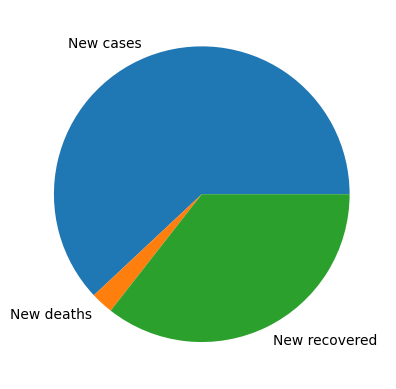

In [77]:
plt.pie(day_wise_df[num_col[4:7]].sum(),labels = num_col[4:7])
plt.show()

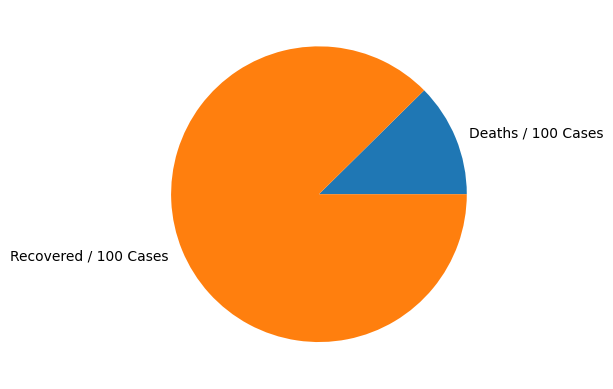

In [78]:
plt.pie(day_wise_df[num_col[7:9]].sum(),labels = num_col[7:9])
plt.show()

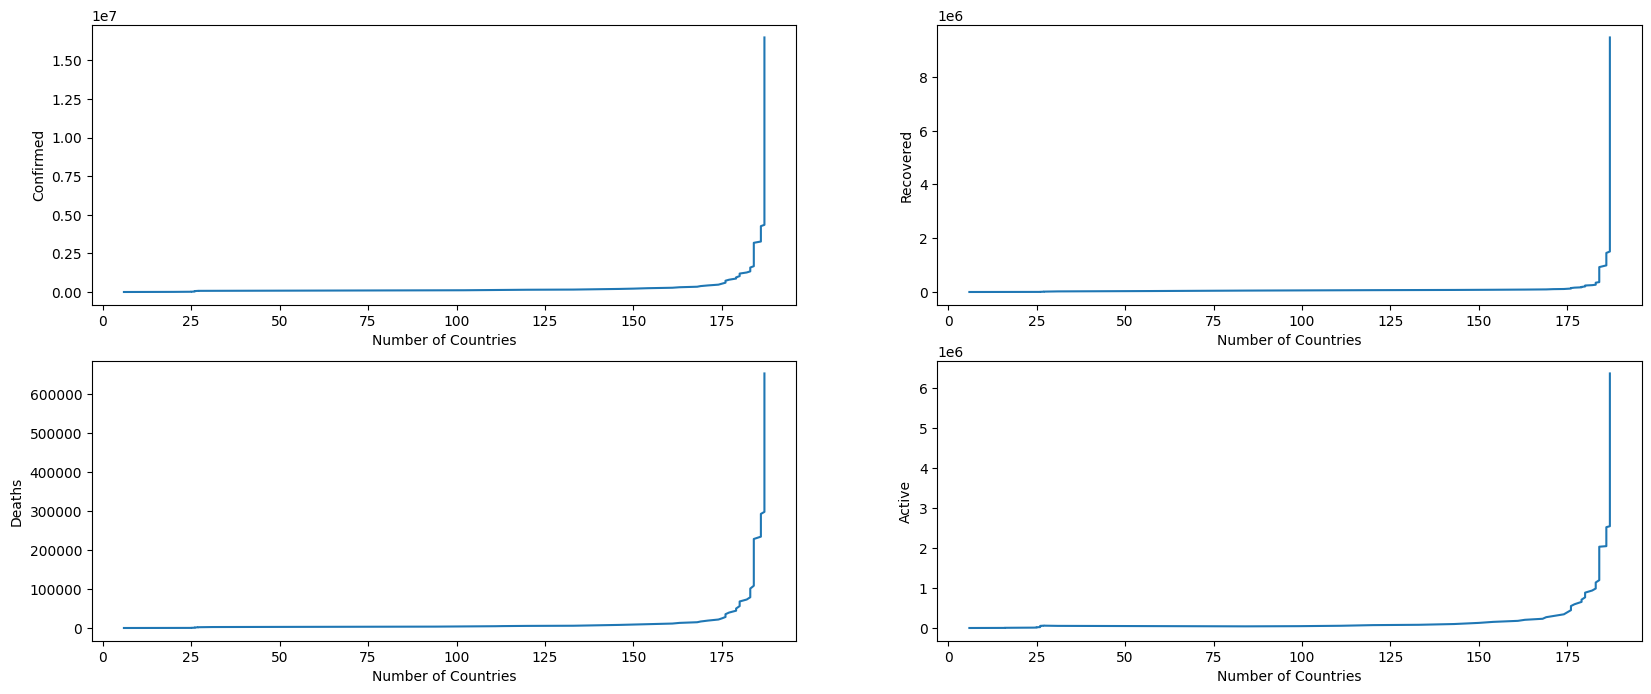

In [79]:
plt.figure(figsize=(20, 8))

plt.subplot(2, 2, 1)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[0]])
plt.xlabel("Number of Countries")
plt.ylabel("Confirmed")

plt.subplot(2, 2, 2)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[2]])
plt.xlabel("Number of Countries")
plt.ylabel("Recovered")

plt.subplot(2, 2, 3)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[1]])
plt.xlabel("Number of Countries")
plt.ylabel("Deaths")

plt.subplot(2, 2, 4)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[3]])
plt.xlabel("Number of Countries")
plt.ylabel("Active")
plt.show()

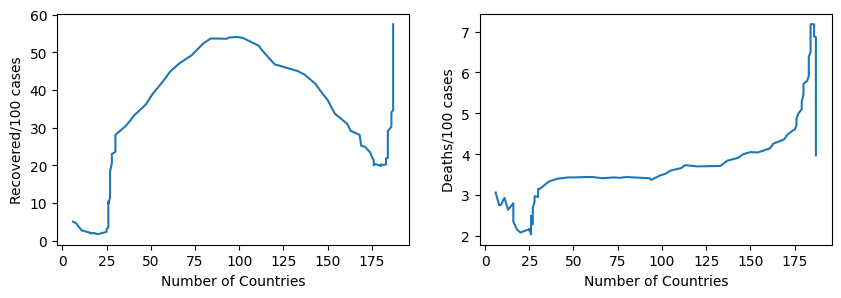

In [80]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[-3]])
plt.xlabel("Number of Countries")
plt.ylabel("Recovered/100 cases")

plt.subplot(1, 2, 2)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[-4]])
plt.xlabel("Number of Countries")
plt.ylabel("Deaths/100 cases")

plt.show()

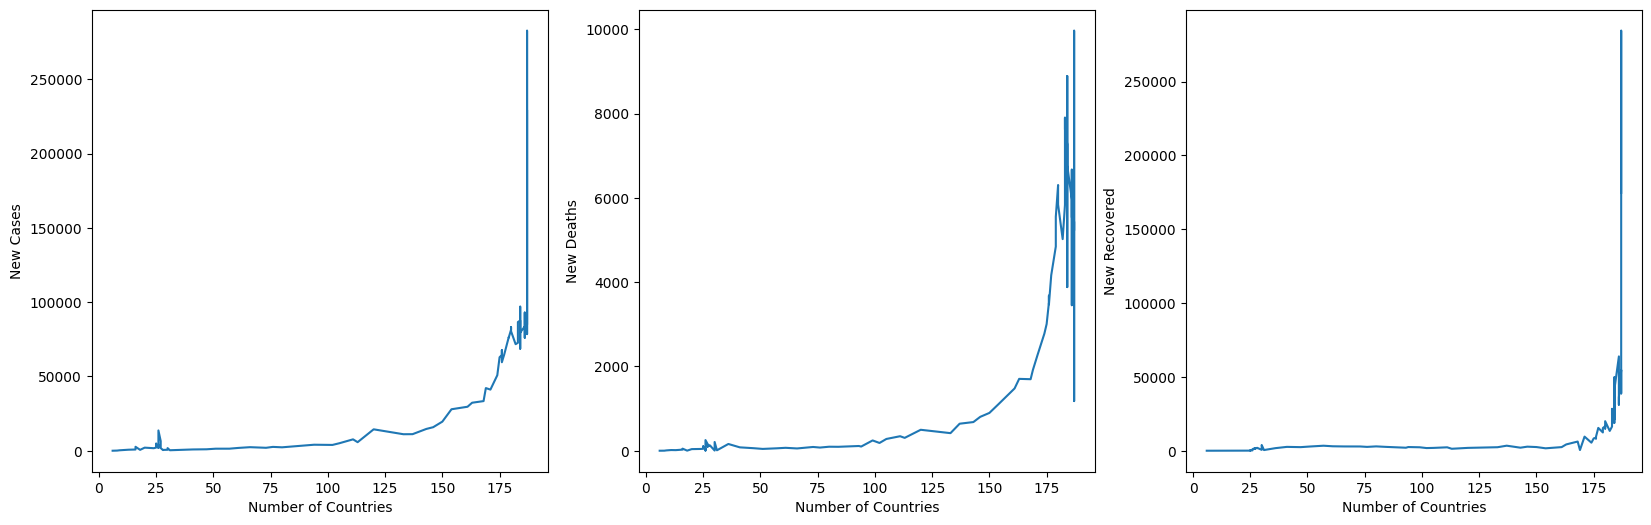

In [81]:
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[4]])
plt.xlabel("Number of Countries")
plt.ylabel("New Cases")

plt.subplot(1, 3, 2)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[5]])
plt.xlabel("Number of Countries")
plt.ylabel("New Deaths")

plt.subplot(1, 3, 3)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[6]])
plt.xlabel("Number of Countries")
plt.ylabel("New Recovered")

plt.show()

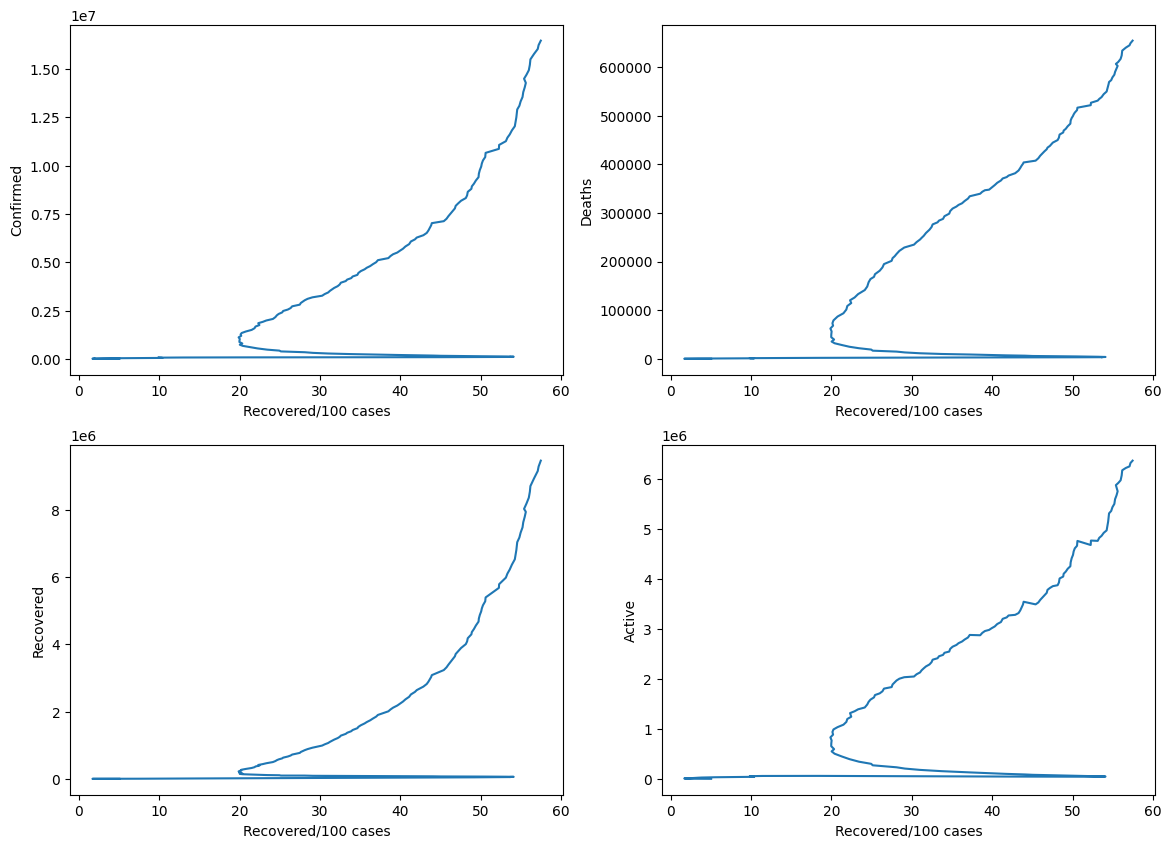

In [82]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(day_wise_df[num_col[-3]], day_wise_df[num_col[0]])
plt.xlabel("Recovered/100 cases")
plt.ylabel("Confirmed")

plt.subplot(2, 2, 2)
plt.plot(day_wise_df[num_col[-3]], day_wise_df[num_col[1]])
plt.xlabel("Recovered/100 cases")
plt.ylabel("Deaths")

plt.subplot(2, 2, 3)
plt.plot(day_wise_df[num_col[-3]], day_wise_df[num_col[2]])
plt.xlabel("Recovered/100 cases")
plt.ylabel("Recovered")

plt.subplot(2, 2, 4)
plt.plot(day_wise_df[num_col[-3]], day_wise_df[num_col[3]])
plt.xlabel("Recovered/100 cases")
plt.ylabel("Active")
plt.show()

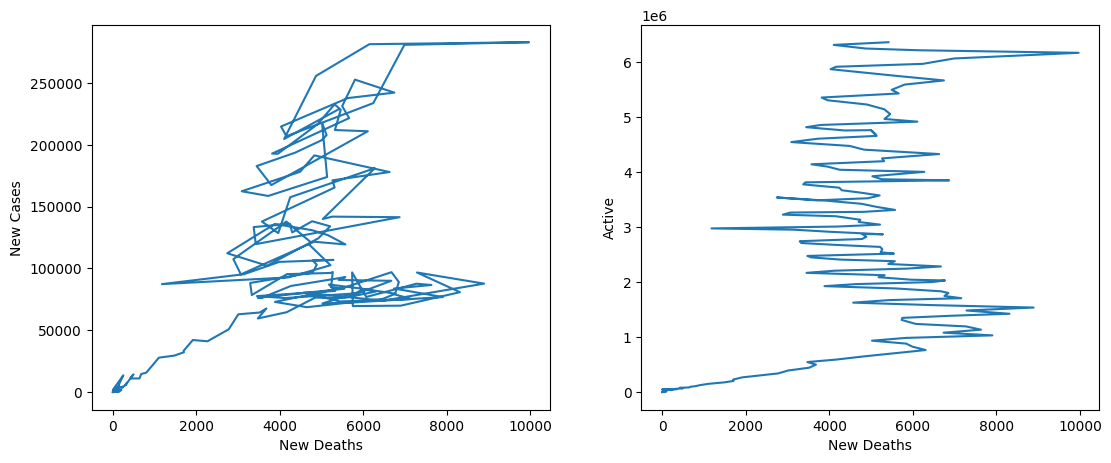

In [83]:
plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(day_wise_df[num_col[5]], day_wise_df[num_col[4]])
plt.xlabel("New Deaths")
plt.ylabel("New Cases")

plt.subplot(1, 2, 2)
plt.plot(day_wise_df[num_col[5]], day_wise_df[num_col[3]])
plt.xlabel("New Deaths")
plt.ylabel("Active")

plt.show()

In [84]:
col_to_remove_ind = [num_col[-4]]
d3 = day_wise_df.drop(col_to_remove_ind, axis=1)

In [85]:
d3.columns

Index(['Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases',
       'New deaths', 'New recovered', 'Recovered / 100 Cases',
       'Deaths / 100 Recovered', 'No. of countries'],
      dtype='object')

#### From the previous analysis we get:
* in the percentage of deaths /100 cases is less than th precentage of recovered/100 cases
* For Active, Recovered, Deaths and Confirmed Columns the Confirmed column takes the highest precentage and after that Active
* For New cases, New Recovered and New Deaths Columns the New cases column takes the highest precentage and after that New Recovered
* For Total cases, Total Recovered and Total Deaths Columns the Total cases column takes the highest precentage and after that Total Recovered
* There is a high change in covid 19 total different cases when the number of countries is greater than 175
* for Recovered/ 100 cases with number of countries the cases start with high value then it decreases then increaing starting from 150 to 175 then it decreases againg
* for Deaths/100 cases with the number of countries the cases start with small value then it reaches its global maximum value at 100 then it decreases then increases and so on
* As Deaths/100 cases has low correlation with target so it was removed

### Working with full_grouped dataset

In [86]:
col,num_col = cal_col(full_grouped_df)

In [87]:
full_grouped_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            35156 non-null  object
 1   Country/Region  35156 non-null  object
 2   Confirmed       35156 non-null  int64 
 3   Deaths          35156 non-null  int64 
 4   Recovered       35156 non-null  int64 
 5   Active          35156 non-null  int64 
 6   New cases       35156 non-null  int64 
 7   New deaths      35156 non-null  int64 
 8   New recovered   35156 non-null  int64 
 9   WHO Region      35156 non-null  object
dtypes: int64(7), object(3)
memory usage: 2.7+ MB


In [88]:
full_grouped_df['Date'] = pd.to_datetime(full_grouped_df['Date'])

In [89]:
full_grouped_df.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


In [90]:
full_grouped_df.tail(10)

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
35146,2020-07-27,United Kingdom,301708,45844,1437,254427,688,7,3,Europe
35147,2020-07-27,Uruguay,1202,35,951,216,10,1,3,Americas
35148,2020-07-27,Uzbekistan,21209,121,11674,9414,678,5,569,Europe
35149,2020-07-27,Venezuela,15988,146,9959,5883,525,4,213,Americas
35150,2020-07-27,Vietnam,431,0,365,66,11,0,0,Western Pacific
35151,2020-07-27,West Bank and Gaza,10621,78,3752,6791,152,2,0,Eastern Mediterranean
35152,2020-07-27,Western Sahara,10,1,8,1,0,0,0,Africa
35153,2020-07-27,Yemen,1691,483,833,375,10,4,36,Eastern Mediterranean
35154,2020-07-27,Zambia,4552,140,2815,1597,71,1,465,Africa
35155,2020-07-27,Zimbabwe,2704,36,542,2126,192,2,24,Africa


In [91]:
full_grouped_df[full_grouped_df['Country/Region']=='United Kingdom'].tail(20)

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
31593,2020-07-08,United Kingdom,288511,44602,1378,242531,637,126,3,Europe
31780,2020-07-09,United Kingdom,289154,44687,1378,243089,643,85,0,Europe
31967,2020-07-10,United Kingdom,289678,44735,1378,243565,524,48,0,Europe
32154,2020-07-11,United Kingdom,290504,44883,1378,244243,826,148,0,Europe
32341,2020-07-12,United Kingdom,291154,44904,1378,244872,650,21,0,Europe
32528,2020-07-13,United Kingdom,291691,44915,1384,245392,537,11,6,Europe
32715,2020-07-14,United Kingdom,292931,45053,1385,246493,1240,138,1,Europe
32902,2020-07-15,United Kingdom,293469,45138,1386,246945,538,85,1,Europe
33089,2020-07-16,United Kingdom,294116,45204,1403,247509,647,66,17,Europe
33276,2020-07-17,United Kingdom,294803,45318,1403,248082,687,114,0,Europe


In [92]:
full_grouped_df[num_col].describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered
count,3.515600e+04,35156.000000,3.515600e+04,3.515600e+04,35156.00000,35156.000000,35156.000000
mean,2.356663e+04,1234.068239,1.104813e+04,1.128443e+04,469.36375,18.603339,269.315593
std,1.499818e+05,7437.238354,6.454640e+04,8.997149e+04,3005.86754,115.706351,2068.063852
min,0.000000e+00,0.000000,0.000000e+00,-2.000000e+00,0.00000,-1918.000000,-16298.000000
25%,1.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000
50%,2.500000e+02,4.000000,3.300000e+01,8.500000e+01,2.00000,0.000000,0.000000
75%,3.640250e+03,78.250000,1.286250e+03,1.454000e+03,75.00000,1.000000,20.000000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,77255.00000,3887.000000,140050.000000


In [93]:
full_grouped_df[full_grouped_df['New deaths']<0].count()

Date              38
Country/Region    38
Confirmed         38
Deaths            38
Recovered         38
Active            38
New cases         38
New deaths        38
New recovered     38
WHO Region        38
dtype: int64

In [94]:
full_grouped_df = full_grouped_df.sort_values(['Country/Region', 'Date']).reset_index(drop=True)

In [95]:
full_grouped_df['pre Confirmed'] = full_grouped_df['Confirmed'].shift(1)
full_grouped_df['pre Deaths'] = full_grouped_df['Deaths'].shift(1)
full_grouped_df['pre Recovered'] = full_grouped_df['Recovered'].shift(1)
full_grouped_df['pre Active'] = full_grouped_df['Active'].shift(1)
full_grouped_df['pre New deaths'] = full_grouped_df['New deaths'].shift(1)
full_grouped_df['pre New recovered'] = full_grouped_df['New recovered'].shift(1)
full_grouped_df.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region,pre Confirmed,pre Deaths,pre Recovered,pre Active,pre New deaths,pre New recovered
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-23,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean,0.0,0.0,0.0,0.0,0.0,0.0
2,2020-01-24,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean,0.0,0.0,0.0,0.0,0.0,0.0
3,2020-01-25,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean,0.0,0.0,0.0,0.0,0.0,0.0
4,2020-01-26,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean,0.0,0.0,0.0,0.0,0.0,0.0


In [96]:
full_grouped_df[(full_grouped_df['Active']< 0)]\
    [['Country/Region','Confirmed','Active','New cases','pre Confirmed','pre Active']]

,Country/Region,Confirmed,Active,New cases,pre Confirmed,pre Active
18953,Liechtenstein,82,-1,0,82.0,0.0
32892,Uganda,1069,-2,4,1065.0,42.0


In [97]:
cond = full_grouped_df['Active']< 0
full_grouped_df.loc[cond,'Active'] = full_grouped_df.loc[cond,'pre Active'] + full_grouped_df.loc[cond,'New cases']

In [98]:
full_grouped_df[(full_grouped_df['New deaths']< 0)]\
    [['Country/Region','Confirmed','Deaths','New deaths','pre Confirmed','pre Deaths','pre New deaths']]

,Country/Region,Confirmed,Deaths,New deaths,pre Confirmed,pre Deaths,pre New deaths
1635,Australia,7221,102,-1,7202.0,103.0,0.0
1873,Austria,19827,710,-1,19743.0,711.0,0.0
8534,Cyprus,446,9,-2,426.0,11.0,0.0
8765,Czechia,8586,297,-1,8475.0,298.0,2.0
8789,Czechia,9855,328,-2,9824.0,330.0,2.0
8791,Czechia,9991,328,-1,9938.0,329.0,1.0
8806,Czechia,11603,348,-1,11298.0,349.0,0.0
8812,Czechia,12440,351,-2,12319.0,353.0,0.0
8813,Czechia,12515,348,-3,12440.0,351.0,-2.0
8947,Denmark,10778,527,-6,10700.0,533.0,4.0


In [99]:
full_grouped_df[(full_grouped_df['New recovered']< 0)]\
    [['Country/Region','Confirmed','Recovered','New recovered','pre Confirmed','pre Recovered','pre New recovered']]

,Country/Region,Confirmed,Recovered,New recovered,pre Confirmed,pre Recovered,pre New recovered
438,Algeria,264,24,-41,230.0,65.0,0.0
440,Algeria,367,29,-36,302.0,65.0,41.0
500,Algeria,8503,4747,-37,8306.0,4784.0,358.0
615,Andorra,1,0,-1,1.0,1.0,1.0
1631,Australia,7165,6576,-3,7150.0,6579.0,19.0
1675,Australia,9797,7727,-6,9553.0,7733.0,157.0
1747,Austria,1332,1,-5,1018.0,6.0,0.0
1940,Azerbaijan,65,10,-1,53.0,11.0,5.0
2141,Bahamas,28,0,-1,24.0,1.0,0.0
2168,Bahamas,81,24,-1,81.0,25.0,2.0


In [100]:
full_grouped_df[(full_grouped_df['New recovered']< 0) | (full_grouped_df['New deaths']< 0)].shape[0]

113

In [101]:
precent = ((113 / full_grouped_df.shape[0] )/100) * 100
precent

0.0032142450790761177

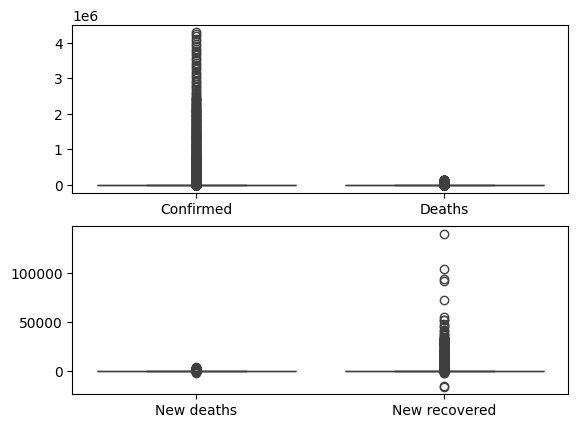

In [102]:
plt.subplot(2,1,1)
sns.boxplot(data= full_grouped_df[col[:4]])

plt.subplot(2,1,2)
sns.boxplot(data= full_grouped_df[col[-3:]])

plt.show()

In [103]:
for i in num_col:
    cap_outliers(full_grouped_df,i)

precentage of outliers in column Confirmed is 17.96%
precentage of outliers in column Deaths is 18.43%
precentage of outliers in column Recovered is 17.68%
precentage of outliers in column Active is 17.93%
precentage of outliers in column New cases is 18.06%
precentage of outliers in column New deaths is 20.96%
precentage of outliers in column New recovered is 18.98%


In [104]:
full_grouped_df.drop_duplicates(keep = 'first',inplace = True)
full_grouped_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               35156 non-null  datetime64[ns]
 1   Country/Region     35156 non-null  object        
 2   Confirmed          35156 non-null  int64         
 3   Deaths             35156 non-null  int64         
 4   Recovered          35156 non-null  int64         
 5   Active             35156 non-null  int64         
 6   New cases          35156 non-null  int64         
 7   New deaths         35156 non-null  int64         
 8   New recovered      35156 non-null  int64         
 9   WHO Region         35156 non-null  object        
 10  pre Confirmed      35155 non-null  float64       
 11  pre Deaths         35155 non-null  float64       
 12  pre Recovered      35155 non-null  float64       
 13  pre Active         35155 non-null  float64       
 14  pre Ne

#### Limitations on the dataset
Upon inspection, approximately 0.32% of the dataset contained logically inconsistent values — specifically, negative values in New deaths and New recovered.
These values directly impact cumulative columns such as Deaths, and thus, were not removed or replaced to avoid distorting the trends.
The analysis was performed on the raw dataset, with full awareness of these anomalies, and we recommend considering them when interpreting the visualizations.


### Working with usa_county_wise dataset

In [105]:
col,num_col = cal_col(usa_county_wise_df)

In [106]:
usa_county_wise_df.head()

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,Combined_Key,Date,Confirmed,Deaths
0,16,AS,ASM,16,60.0,NaN,American Samoa,US,-14.271000,-170.132000,"American Samoa, US",1/22/20,0,0
1,316,GU,GUM,316,66.0,NaN,Guam,US,13.444300,144.793700,"Guam, US",1/22/20,0,0
2,580,MP,MNP,580,69.0,NaN,Northern Mariana Islands,US,15.097900,145.673900,"Northern Mariana Islands, US",1/22/20,0,0
3,63072001,PR,PRI,630,72001.0,Adjuntas,Puerto Rico,US,18.180117,-66.754367,"Adjuntas, Puerto Rico, US",1/22/20,0,0
4,63072003,PR,PRI,630,72003.0,Aguada,Puerto Rico,US,18.360255,-67.175131,"Aguada, Puerto Rico, US",1/22/20,0,0


In [107]:
usa_county_wise_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 627920 entries, 0 to 627919
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   UID             627920 non-null  int64  
 1   iso2            627920 non-null  object 
 2   iso3            627920 non-null  object 
 3   code3           627920 non-null  int64  
 4   FIPS            626040 non-null  float64
 5   Admin2          626792 non-null  object 
 6   Province_State  627920 non-null  object 
 7   Country_Region  627920 non-null  object 
 8   Lat             627920 non-null  float64
 9   Long_           627920 non-null  float64
 10  Combined_Key    627920 non-null  object 
 11  Date            627920 non-null  object 
 12  Confirmed       627920 non-null  int64  
 13  Deaths          627920 non-null  int64  
dtypes: float64(3), int64(4), object(7)
memory usage: 67.1+ MB


In [108]:
usa_county_wise_df.describe()

,UID,code3,FIPS,Lat,Long_,Confirmed,Deaths
count,6.279200e+05,627920.000000,626040.000000,627920.000000,627920.000000,627920.000000,627920.000000
mean,8.342958e+07,834.491617,33061.684685,36.707212,-88.601474,357.284285,17.536328
std,4.314702e+06,36.492620,18636.156825,9.061572,21.715747,3487.282694,300.991466
min,1.600000e+01,16.000000,60.000000,-14.271000,-174.159600,0.000000,0.000000
25%,8.401811e+07,840.000000,19079.000000,33.895587,-97.790204,0.000000,0.000000
50%,8.402921e+07,840.000000,31014.000000,38.002344,-89.486710,4.000000,0.000000
75%,8.404612e+07,840.000000,47131.000000,41.573069,-82.311265,63.000000,1.000000
max,8.410000e+07,850.000000,99999.000000,69.314792,145.673900,224051.000000,23500.000000


In [109]:
usa_county_wise_df[['Admin2','FIPS']].nunique()

Admin2    1978
FIPS      3330
dtype: int64

In [110]:
usa_county_wise_df[usa_county_wise_df['Admin2'].isna()][['Admin2','Combined_Key']].drop_duplicates()

,Admin2,Combined_Key
0,NaN,"American Samoa, US"
1,NaN,"Guam, US"
2,NaN,"Northern Mariana Islands, US"
81,NaN,"Virgin Islands, US"
3276,NaN,"Diamond Princess, US"
3329,NaN,"Grand Princess, US"


In [111]:
usa_county_wise_df[usa_county_wise_df['FIPS'].isna()][['Admin2','FIPS']].drop_duplicates()

,Admin2,FIPS
3330,Dukes and Nantucket,NaN
3331,Kansas City,NaN
3332,Michigan Department of Corrections (MDOC),NaN
3333,Federal Correctional Institution (FCI),NaN
3334,Bear River,NaN
3335,Central Utah,NaN
3336,Southeast Utah,NaN
3337,Southwest Utah,NaN
3338,TriCounty,NaN
3339,Weber-Morgan,NaN


In [112]:
usa_county_wise_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 627920 entries, 0 to 627919
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   UID             627920 non-null  int64  
 1   iso2            627920 non-null  object 
 2   iso3            627920 non-null  object 
 3   code3           627920 non-null  int64  
 4   FIPS            626040 non-null  float64
 5   Admin2          626792 non-null  object 
 6   Province_State  627920 non-null  object 
 7   Country_Region  627920 non-null  object 
 8   Lat             627920 non-null  float64
 9   Long_           627920 non-null  float64
 10  Combined_Key    627920 non-null  object 
 11  Date            627920 non-null  object 
 12  Confirmed       627920 non-null  int64  
 13  Deaths          627920 non-null  int64  
dtypes: float64(3), int64(4), object(7)
memory usage: 67.1+ MB


In [113]:
drop_na_df = usa_county_wise_df.dropna(how ='any',axis = 0).copy()
drop_na_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 624912 entries, 3 to 627908
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   UID             624912 non-null  int64  
 1   iso2            624912 non-null  object 
 2   iso3            624912 non-null  object 
 3   code3           624912 non-null  int64  
 4   FIPS            624912 non-null  float64
 5   Admin2          624912 non-null  object 
 6   Province_State  624912 non-null  object 
 7   Country_Region  624912 non-null  object 
 8   Lat             624912 non-null  float64
 9   Long_           624912 non-null  float64
 10  Combined_Key    624912 non-null  object 
 11  Date            624912 non-null  object 
 12  Confirmed       624912 non-null  int64  
 13  Deaths          624912 non-null  int64  
dtypes: float64(3), int64(4), object(7)
memory usage: 71.5+ MB


In [114]:
calculate_percentage = (drop_na_df.shape[0]/usa_county_wise_df.shape[0]) * 100
calculate_percentage

99.52095808383234

In [115]:
drop_na_df['Date'] = pd.to_datetime(drop_na_df['Date'],format='%m/%d/%y')

In [116]:
drop_na_df.drop_duplicates(inplace=True)

In [117]:
drop_na_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 624912 entries, 3 to 627908
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   UID             624912 non-null  int64         
 1   iso2            624912 non-null  object        
 2   iso3            624912 non-null  object        
 3   code3           624912 non-null  int64         
 4   FIPS            624912 non-null  float64       
 5   Admin2          624912 non-null  object        
 6   Province_State  624912 non-null  object        
 7   Country_Region  624912 non-null  object        
 8   Lat             624912 non-null  float64       
 9   Long_           624912 non-null  float64       
 10  Combined_Key    624912 non-null  object        
 11  Date            624912 non-null  datetime64[ns]
 12  Confirmed       624912 non-null  int64         
 13  Deaths          624912 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(4

In [118]:
drop_na_df['Country_Region'].unique()

array(['US'], dtype=object)

In [119]:
drop_na_df.rename(columns={'Long_': 'Long'}, inplace=True)

In [120]:
col,num_col = cal_col(drop_na_df)

In [121]:
cap_outliers(usa_county_wise_df,'Confirmed')
cap_outliers(usa_county_wise_df,'Deaths')

precentage of outliers in column Confirmed is 16.33%
precentage of outliers in column Deaths is 19.72%


#### Apply Plotting

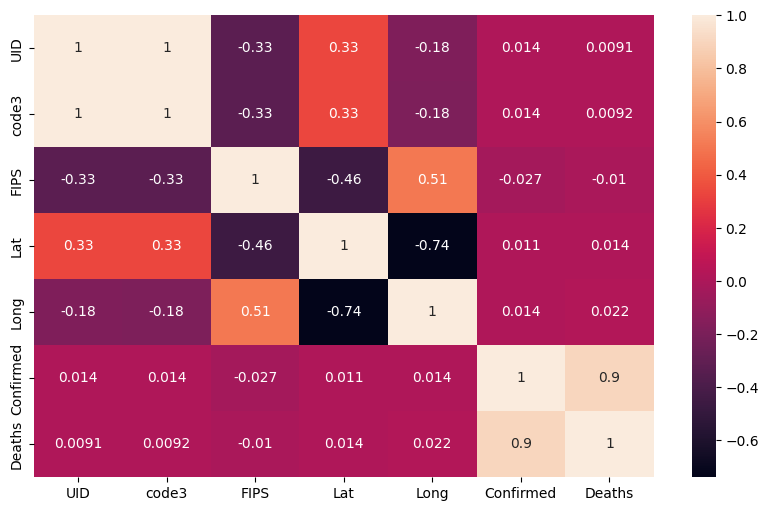

In [122]:
plt.figure(figsize=(10, 6))
cal_corr(num_col,drop_na_df)

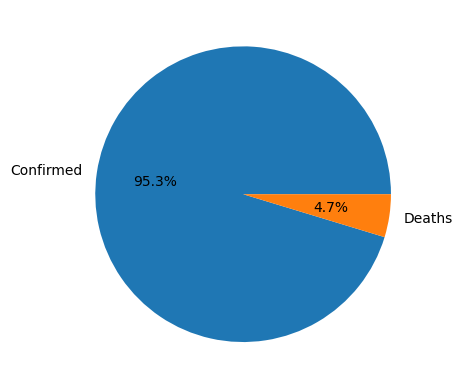

In [123]:
data = drop_na_df[num_col[-2:]].sum()
plt.pie(data,labels = num_col[-2:],autopct = '%1.1F%%')
plt.show()

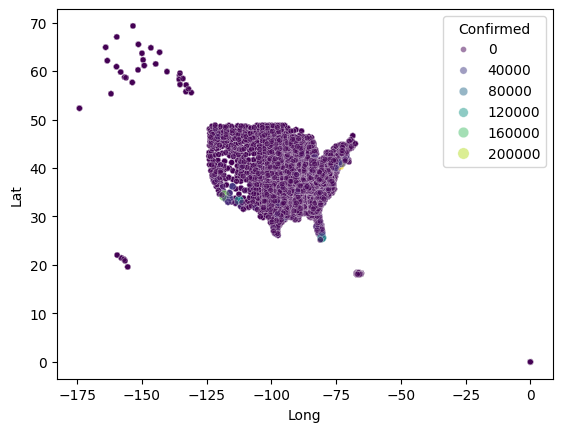

In [124]:
sns.scatterplot(
    data = drop_na_df,
    x = num_col[-3],
    y = num_col[-4],
    size = num_col[-2],
    hue = num_col[-2],
    palette="viridis",
    alpha=0.5,
)
plt.show()

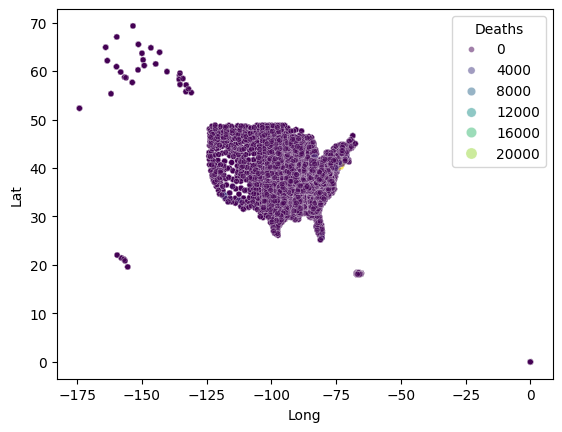

In [125]:
sns.scatterplot(
    data = drop_na_df,
    x = num_col[-3],
    y = num_col[-4],
    size = num_col[-1],
    hue = num_col[-1],
    palette="viridis",
    alpha=0.5,
)
plt.show()

In [126]:
d5 = drop_na_df[[num_col[-1],num_col[-2],'Country_Region','Date','Province_State']]

#### From the pervious analysis
* we will find that a high percentage of confirmed and deaths in USA is in between -70 and -127 in longtitude and -25 to -50 in latitude  
* as the Country_Region column contains only usa value then it isn't gonna be useful in the model so we are gonna drop it
* as Combined_Key column are splitted into Admin2, Province_State, Country_Region columns so we can drop it  

### Working with worldometer_data dataset

In [127]:
col,num_col = cal_col(worldometer_data_df)

In [128]:
worldometer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country/Region    209 non-null    object 
 1   Continent         208 non-null    object 
 2   Population        208 non-null    float64
 3   TotalCases        209 non-null    int64  
 4   NewCases          4 non-null      float64
 5   TotalDeaths       188 non-null    float64
 6   NewDeaths         3 non-null      float64
 7   TotalRecovered    205 non-null    float64
 8   NewRecovered      3 non-null      float64
 9   ActiveCases       205 non-null    float64
 10  Serious,Critical  122 non-null    float64
 11  Tot Cases/1M pop  208 non-null    float64
 12  Deaths/1M pop     187 non-null    float64
 13  TotalTests        191 non-null    float64
 14  Tests/1M pop      191 non-null    float64
 15  WHO Region        184 non-null    object 
dtypes: float64(12), int64(1), object(3)
memory u

In [129]:
worldometer_data_df = dropping_col_based_on_nulls_precentage(worldometer_data_df)

In [130]:
worldometer_data_df.head()

,Country/Region,Continent,Population,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,162804.0,2576668.0,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,98644.0,2047660.0,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,41638.0,1377384.0,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,14606.0,676357.0,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,9604.0,387316.0,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa


In [131]:
worldometer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country/Region    209 non-null    object 
 1   Continent         208 non-null    object 
 2   Population        208 non-null    float64
 3   TotalCases        209 non-null    int64  
 4   TotalDeaths       188 non-null    float64
 5   TotalRecovered    205 non-null    float64
 6   ActiveCases       205 non-null    float64
 7   Serious,Critical  122 non-null    float64
 8   Tot Cases/1M pop  208 non-null    float64
 9   Deaths/1M pop     187 non-null    float64
 10  TotalTests        191 non-null    float64
 11  Tests/1M pop      191 non-null    float64
 12  WHO Region        184 non-null    object 
dtypes: float64(9), int64(1), object(3)
memory usage: 21.4+ KB


In [132]:
# Renaming columns:
worldometer_data_df.rename(columns={'TotalCases': 'Total Cases','TotalDeaths':'Total Deaths','TotalRecovered':'Total Recovered','ActiveCases':'Active Cases','Serious,Critical':'Serious/Critical'\
                                   ,'Tot Cases/1M pop': 'Total Cases/1M pop', 'TotalTests':'Total Tests'}, inplace=True)

In [133]:
worldometer_data_df[worldometer_data_df['Continent'].isna()][['Continent','Country/Region']].drop_duplicates()

,Continent,Country/Region
156,NaN,Diamond Princess


In [134]:
worldometer_data_df[worldometer_data_df['Country/Region'] == 'Diamond Princess'][['Continent','Country/Region']]

,Continent,Country/Region
156,NaN,Diamond Princess


In [135]:
# dropping null values in 'Country/Region' and population
worldometer_data_df.dropna(subset = ['Country/Region','Population'],inplace = True)

In [136]:
worldometer_data_df[worldometer_data_df['WHO Region'].isna()][['WHO Region','Continent','Country/Region' ]]

,WHO Region,Continent,Country/Region
84,NaN,South America,French Guiana
102,NaN,Africa,CAR
112,NaN,Africa,Mayotte
158,NaN,Africa,Réunion
159,NaN,Europe,Channel Islands
167,NaN,Europe,Isle of Man
170,NaN,North America,Guadeloupe
171,NaN,North America,Martinique
172,NaN,Europe,Faeroe Islands
173,NaN,North America,Aruba


In [137]:
continent_dict = worldometer_data_df.groupby('Continent')['WHO Region'].first().to_dict()
continent_dict

{'Africa': 'Africa',
 'Asia': 'South-EastAsia',
 'Australia/Oceania': 'WesternPacific',
 'Europe': 'Europe',
 'North America': 'Americas',
 'South America': 'Americas'}

In [138]:
worldometer_data_df['WHO Region'] = worldometer_data_df['WHO Region'].fillna(worldometer_data_df['Continent'].map(continent_dict))

In [139]:
worldometer_data_df['WHO Region'].unique()

array(['Americas', 'South-EastAsia', 'Europe', 'Africa',
       'EasternMediterranean', 'WesternPacific'], dtype=object)

In [140]:
worldometer_data_df[worldometer_data_df['Total Tests'].isna()][['Total Tests','Tests/1M pop']]

,Total Tests,Tests/1M pop
54,NaN,NaN
82,NaN,NaN
86,NaN,NaN
106,NaN,NaN
108,NaN,NaN
111,NaN,NaN
130,NaN,NaN
138,NaN,NaN
142,NaN,NaN
145,NaN,NaN


In [141]:
# as Total Tests at least equals total cases then null values in total tests = total cases
worldometer_data_df['Total Tests'] = worldometer_data_df['Total Tests'].fillna(worldometer_data_df['Total Cases'])

In [142]:
# Total cases = Active + deaths + recovered
values_replaced_with = worldometer_data_df['Total Cases'] - (worldometer_data_df['Total Recovered'] + worldometer_data_df['Active Cases'])
worldometer_data_df['Total Deaths'] = worldometer_data_df['Total Deaths'].fillna(values_replaced_with)

In [143]:
col,num_col = cal_col(worldometer_data_df)

In [144]:
worldometer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 208
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country/Region      208 non-null    object 
 1   Continent           208 non-null    object 
 2   Population          208 non-null    float64
 3   Total Cases         208 non-null    int64  
 4   Total Deaths        208 non-null    float64
 5   Total Recovered     204 non-null    float64
 6   Active Cases        204 non-null    float64
 7   Serious/Critical    121 non-null    float64
 8   Total Cases/1M pop  208 non-null    float64
 9   Deaths/1M pop       187 non-null    float64
 10  Total Tests         208 non-null    float64
 11  Tests/1M pop        191 non-null    float64
 12  WHO Region          208 non-null    object 
dtypes: float64(9), int64(1), object(3)
memory usage: 22.8+ KB


In [145]:
# Total cases = Active + deaths + recovered
values_replaced_with = worldometer_data_df['Total Cases'] - (worldometer_data_df['Total Deaths'] + worldometer_data_df['Active Cases'])
worldometer_data_df['Total Recovered'] = worldometer_data_df['Total Recovered'].fillna(values_replaced_with)

replace_values_in_test_percent = (worldometer_data_df['Total Tests'] / worldometer_data_df['Population'] ) *1000000
worldometer_data_df['Tests/1M pop'] = worldometer_data_df['Tests/1M pop'].fillna(replace_values_in_test_percent)

replace_values_in_test_percent = (worldometer_data_df['Total Deaths'] / worldometer_data_df['Population'] ) *1000000
worldometer_data_df['Deaths/1M pop'] = worldometer_data_df['Deaths/1M pop'].fillna(replace_values_in_test_percent)

In [146]:
worldometer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 208
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country/Region      208 non-null    object 
 1   Continent           208 non-null    object 
 2   Population          208 non-null    float64
 3   Total Cases         208 non-null    int64  
 4   Total Deaths        208 non-null    float64
 5   Total Recovered     204 non-null    float64
 6   Active Cases        204 non-null    float64
 7   Serious/Critical    121 non-null    float64
 8   Total Cases/1M pop  208 non-null    float64
 9   Deaths/1M pop       208 non-null    float64
 10  Total Tests         208 non-null    float64
 11  Tests/1M pop        208 non-null    float64
 12  WHO Region          208 non-null    object 
dtypes: float64(9), int64(1), object(3)
memory usage: 22.8+ KB


In [147]:
worldometer_data_df = worldometer_data_df.fillna(0)

In [148]:
worldometer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 208
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country/Region      208 non-null    object 
 1   Continent           208 non-null    object 
 2   Population          208 non-null    float64
 3   Total Cases         208 non-null    int64  
 4   Total Deaths        208 non-null    float64
 5   Total Recovered     208 non-null    float64
 6   Active Cases        208 non-null    float64
 7   Serious/Critical    208 non-null    float64
 8   Total Cases/1M pop  208 non-null    float64
 9   Deaths/1M pop       208 non-null    float64
 10  Total Tests         208 non-null    float64
 11  Tests/1M pop        208 non-null    float64
 12  WHO Region          208 non-null    object 
dtypes: float64(9), int64(1), object(3)
memory usage: 22.8+ KB


In [149]:
worldometer_data_df[num_col] = worldometer_data_df[num_col].astype(int)

In [150]:
worldometer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 208
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country/Region      208 non-null    object
 1   Continent           208 non-null    object
 2   Population          208 non-null    int64 
 3   Total Cases         208 non-null    int64 
 4   Total Deaths        208 non-null    int64 
 5   Total Recovered     208 non-null    int64 
 6   Active Cases        208 non-null    int64 
 7   Serious/Critical    208 non-null    int64 
 8   Total Cases/1M pop  208 non-null    int64 
 9   Deaths/1M pop       208 non-null    int64 
 10  Total Tests         208 non-null    int64 
 11  Tests/1M pop        208 non-null    int64 
 12  WHO Region          208 non-null    object
dtypes: int64(10), object(3)
memory usage: 22.8+ KB


In [151]:
worldometer_data_df.describe()

,Population,Total Cases,Total Deaths,Total Recovered,Active Cases,Serious/Critical,Total Cases/1M pop,Deaths/1M pop,Total Tests,Tests/1M pop
count,2.080000e+02,2.080000e+02,208.000000,2.080000e+02,2.080000e+02,208.000000,208.000000,208.000000,2.080000e+02,208.000000
mean,3.041549e+07,9.215603e+04,3427.855769,5.802663e+04,2.726509e+04,313.423077,3196.024038,88.697115,1.288116e+06,77196.153846
std,1.047661e+08,4.335840e+05,14762.629768,2.549293e+05,1.733942e+05,1587.511422,5191.986457,168.512502,5.334286e+06,148082.071315
min,8.010000e+02,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,3.000000,0.000000,1.000000e+01,4.000000
25%,9.663140e+05,7.312500e+02,11.750000,3.070000e+02,7.400000e+01,0.000000,282.000000,4.000000,1.180775e+04,6494.000000
50%,7.041972e+06,4.544000e+03,73.000000,2.073500e+03,8.620000e+02,2.000000,1015.000000,20.000000,1.123535e+05,29793.500000
75%,2.575614e+07,3.733675e+04,604.250000,1.983525e+04,7.115750e+03,41.250000,3841.750000,82.000000,7.001068e+05,77340.500000
max,1.381345e+09,5.032179e+06,162804.000000,2.576668e+06,2.292707e+06,18296.000000,39922.000000,1238.000000,6.313960e+07,995282.000000


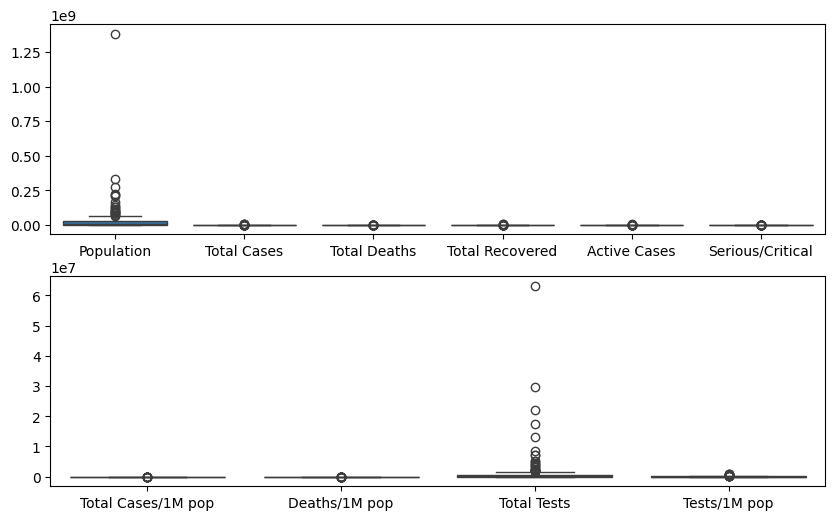

In [152]:
plt.figure(figsize=(10, 6))

plt.subplot(2,1,1)
sns.boxplot(data= worldometer_data_df[num_col[:6]])

plt.subplot(2,1,2)
sns.boxplot(data= worldometer_data_df[num_col[6:]])

plt.show()

In [153]:
for i in num_col:
        cap_outliers(worldometer_data_df,i)

precentage of outliers in column Population is 10.10%
precentage of outliers in column Total Cases is 12.98%
precentage of outliers in column Total Deaths is 18.27%
precentage of outliers in column Total Recovered is 14.42%
precentage of outliers in column Active Cases is 12.98%
precentage of outliers in column Serious/Critical is 16.83%
precentage of outliers in column Total Cases/1M pop is 8.17%
precentage of outliers in column Deaths/1M pop is 14.42%
precentage of outliers in column Total Tests is 11.54%
precentage of outliers in column Tests/1M pop is 8.65%


In [154]:
worldometer_data_df.drop_duplicates(keep = 'first',inplace = True)
worldometer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 208
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country/Region      208 non-null    object
 1   Continent           208 non-null    object
 2   Population          208 non-null    int64 
 3   Total Cases         208 non-null    int64 
 4   Total Deaths        208 non-null    int64 
 5   Total Recovered     208 non-null    int64 
 6   Active Cases        208 non-null    int64 
 7   Serious/Critical    208 non-null    int64 
 8   Total Cases/1M pop  208 non-null    int64 
 9   Deaths/1M pop       208 non-null    int64 
 10  Total Tests         208 non-null    int64 
 11  Tests/1M pop        208 non-null    int64 
 12  WHO Region          208 non-null    object
dtypes: int64(10), object(3)
memory usage: 22.8+ KB


#### Apply Plotting

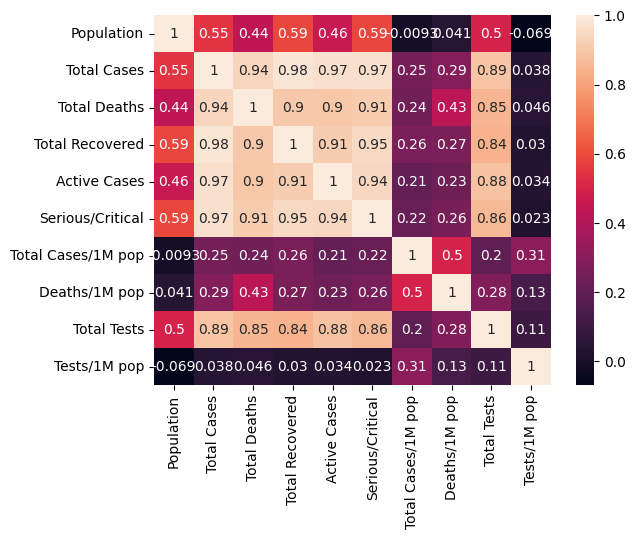

In [155]:
cal_corr(num_col,worldometer_data_df)

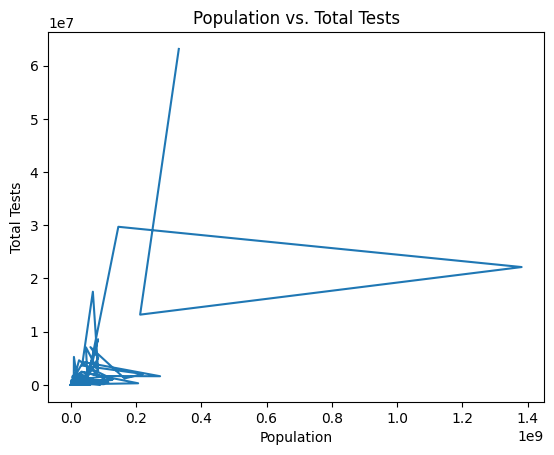

In [156]:
plt.plot( worldometer_data_df[num_col[0]], worldometer_data_df[num_col[-2]])
plt.title("Population vs. Total Tests")
plt.xlabel("Population")
plt.ylabel("Total Tests")
plt.show()

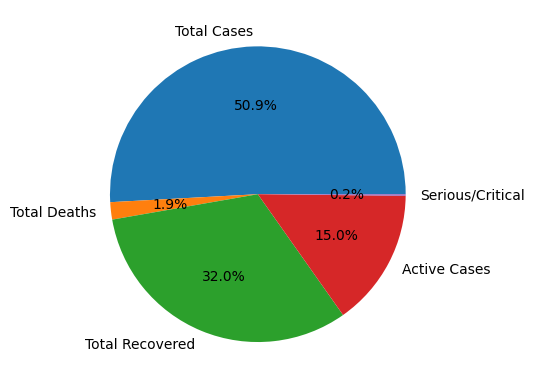

In [157]:
data = worldometer_data_df[num_col[1:6]].sum()
plt.pie(data,labels = num_col[1:6],autopct = '%1.1F%%')
plt.show()

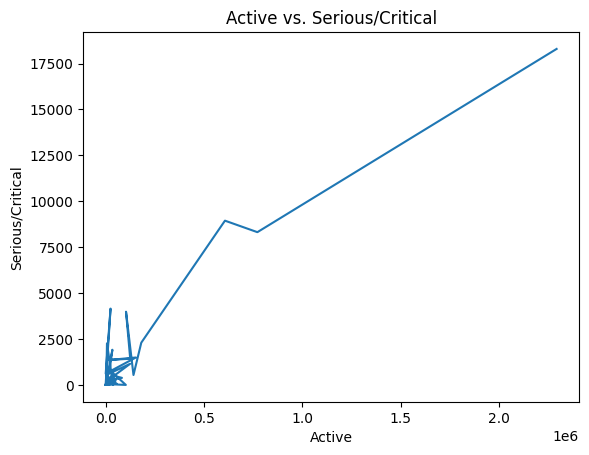

In [158]:
plt.plot( worldometer_data_df[num_col[4]], worldometer_data_df[num_col[5]])
plt.title("Active vs. Serious/Critical")
plt.xlabel("Active")
plt.ylabel("Serious/Critical")
plt.show()

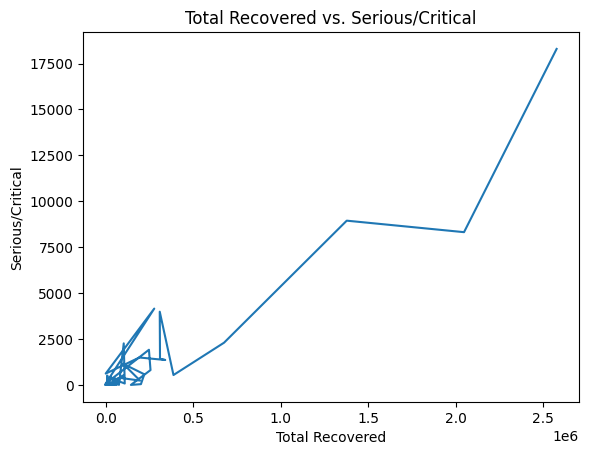

In [159]:
plt.plot( worldometer_data_df[num_col[3]], worldometer_data_df[num_col[5]])
plt.title("Total Recovered vs. Serious/Critical")
plt.xlabel("Total Recovered")
plt.ylabel("Serious/Critical")
plt.show()

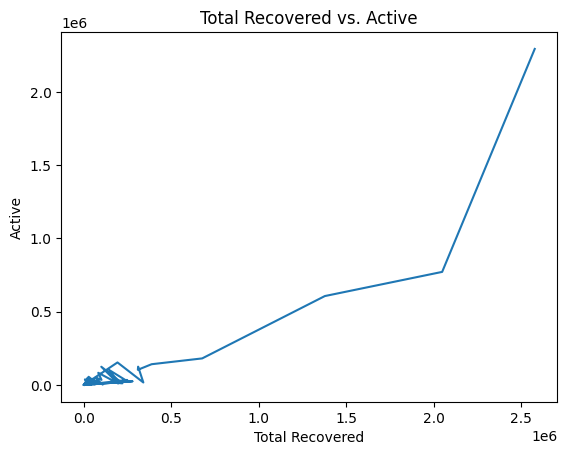

In [160]:
plt.plot( worldometer_data_df[num_col[3]], worldometer_data_df[num_col[4]])
plt.title("Total Recovered vs. Active")
plt.xlabel("Total Recovered")
plt.ylabel("Active")
plt.show()

In [161]:
worldometer_data_df[num_col[1:6]].sum()

Total Cases         19168454
Total Deaths          712994
Total Recovered     12069540
Active Cases         5671139
Serious/Critical       65192
dtype: int64

In [162]:
labels = ['Total Cases','Total Deaths','Total Recovered','Active Cases','Serious/Critical']
vals = list(worldometer_data_df[num_col[1:6]].sum())

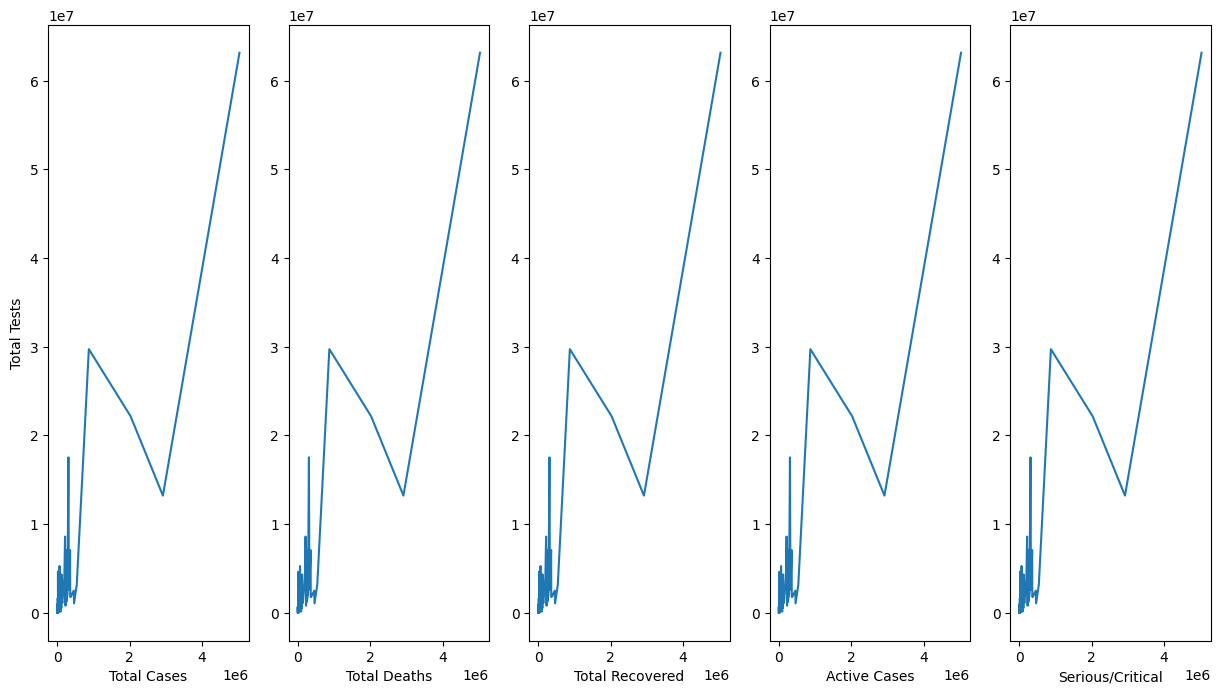

In [163]:
plt.figure(figsize=(15, 8))

plt.subplot(1,5,1)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[-2]])
plt.xlabel("Total Cases")
plt.ylabel("Total Tests")

plt.subplot(1,5,2)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[-2]])
plt.xlabel("Total Deaths")

plt.subplot(1,5,3)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[-2]])
plt.xlabel("Total Recovered")

plt.subplot(1,5,4)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[-2]])
plt.xlabel("Active Cases")

plt.subplot(1,5,5)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[-2]])
plt.xlabel("Serious/Critical")
plt.show()

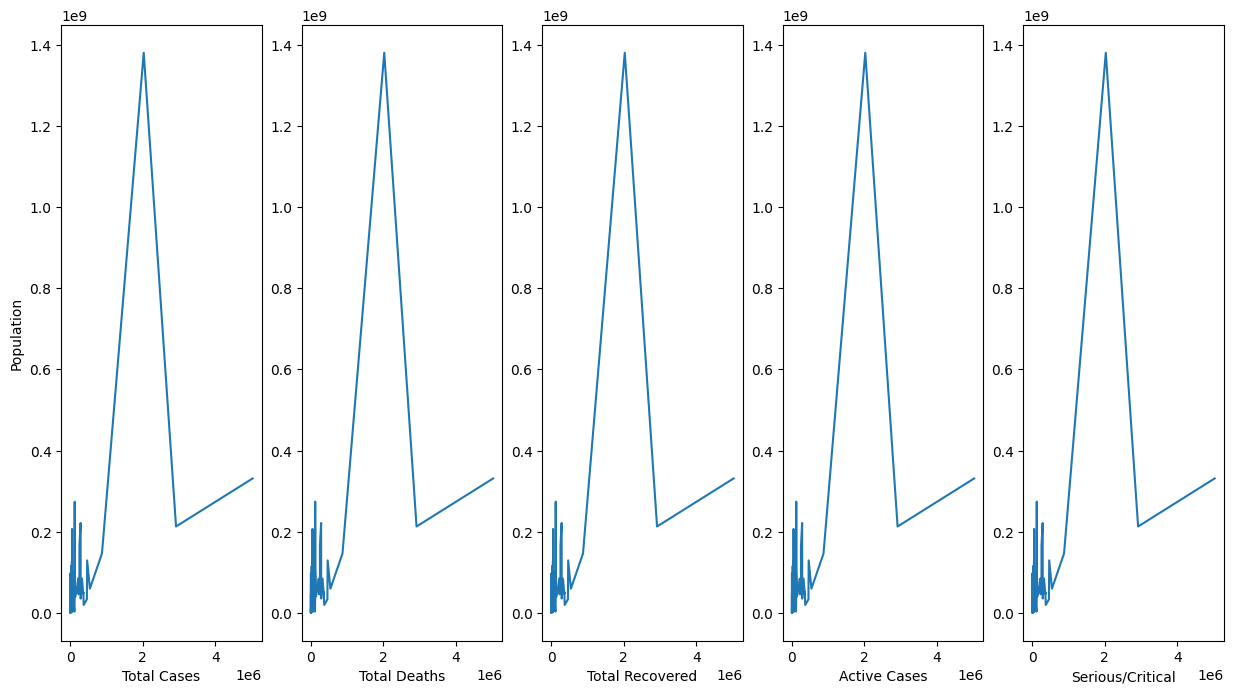

In [164]:
plt.figure(figsize=(15, 8))

plt.subplot(1,5,1)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[0]])
plt.xlabel("Total Cases")
plt.ylabel("Population")

plt.subplot(1,5,2)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[0]])
plt.xlabel("Total Deaths")

plt.subplot(1,5,3)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[0]])
plt.xlabel("Total Recovered")

plt.subplot(1,5,4)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[0]])
plt.xlabel("Active Cases")

plt.subplot(1,5,5)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[0]])
plt.xlabel("Serious/Critical")
plt.show()

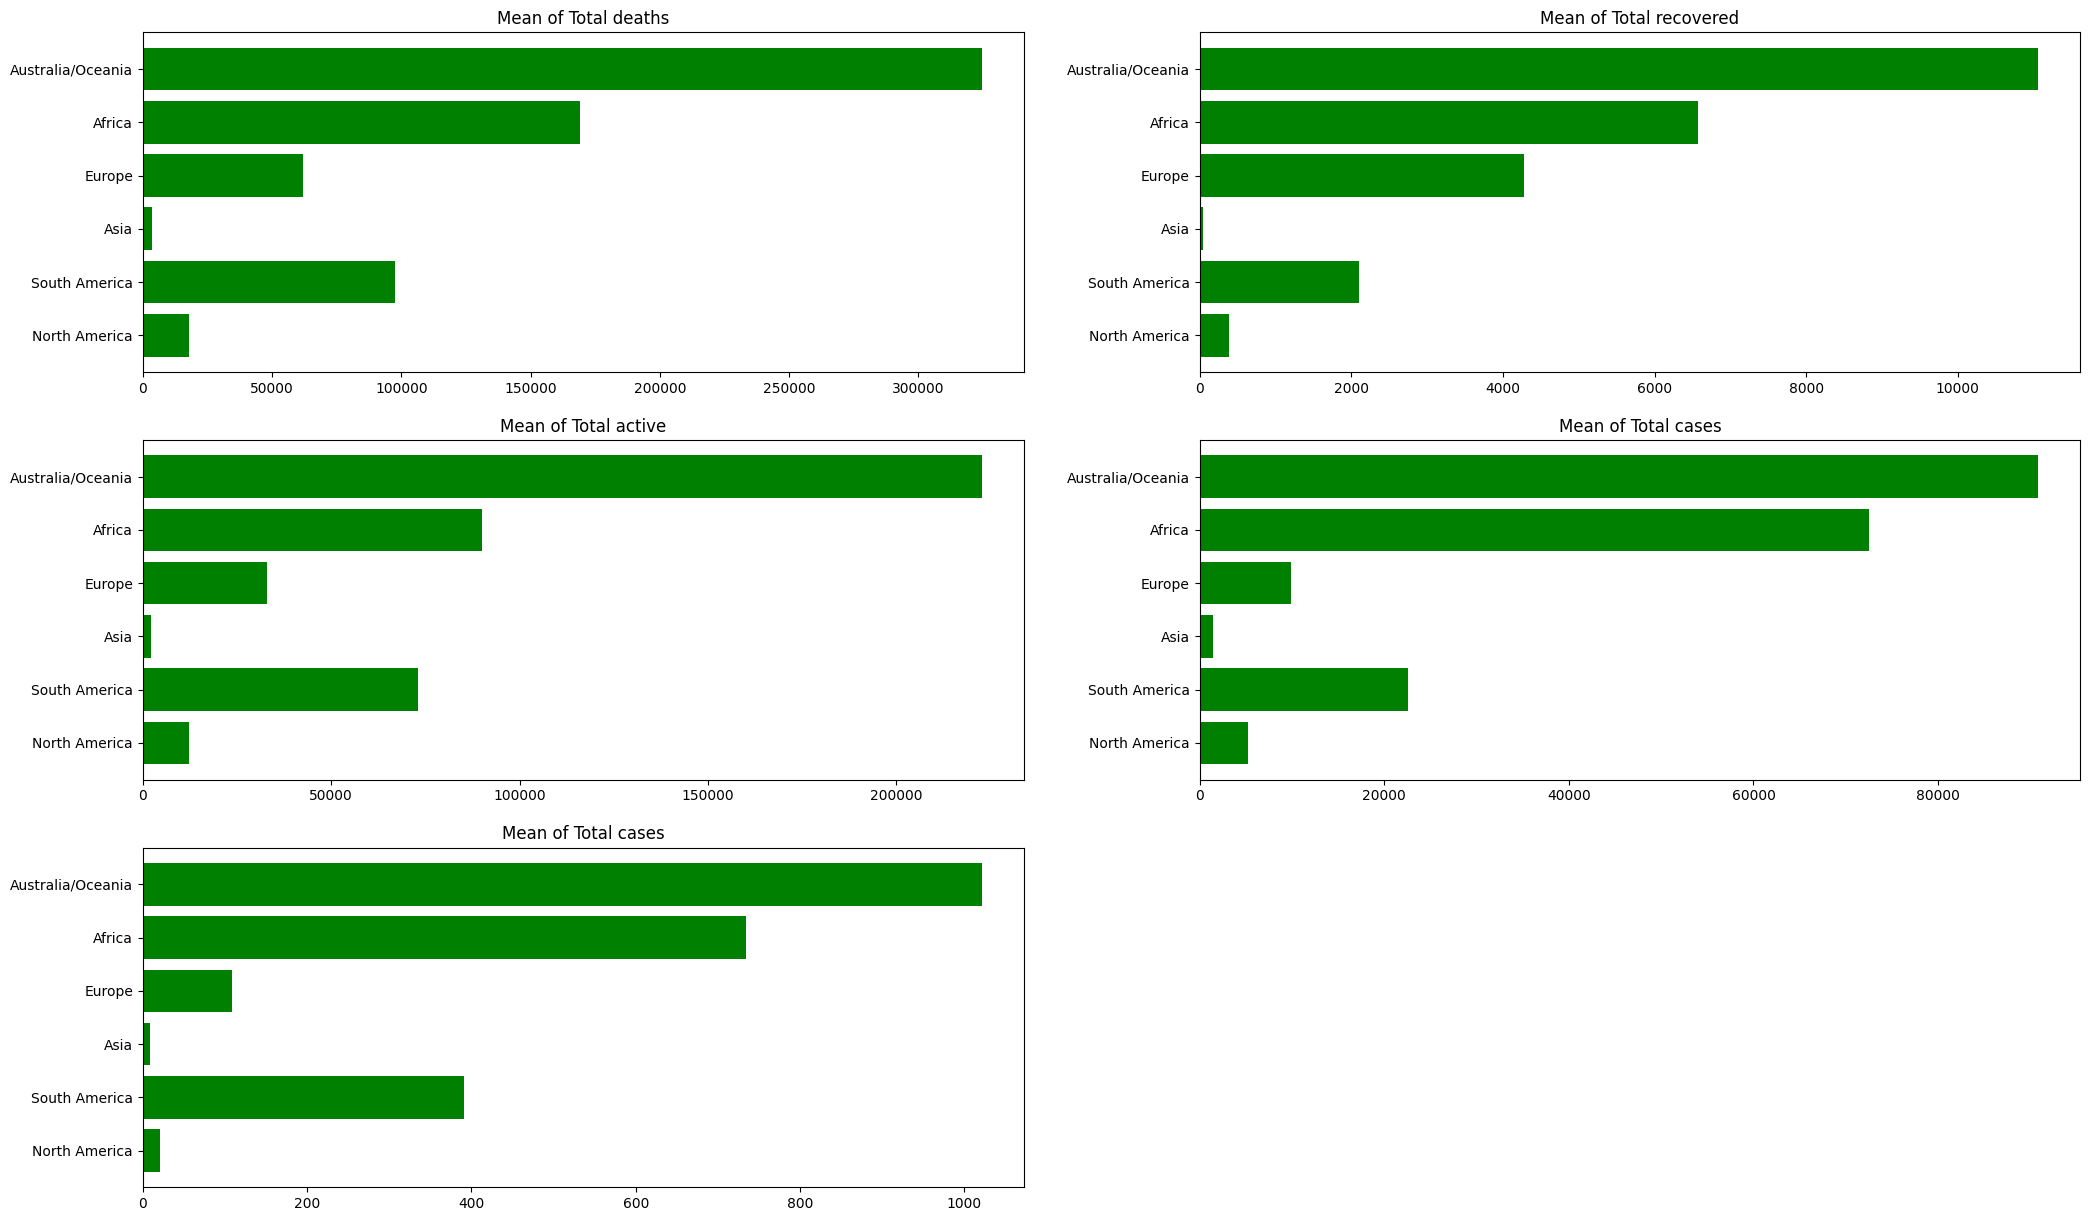

In [165]:
plt.figure(figsize=(25, 15))
plt.subplot(3,2,1)
plt.barh(worldometer_data_df['Continent'].unique(),worldometer_data_df.groupby('Continent')['Total Cases'].mean(),color = 'green')
plt.title('Mean of Total deaths')

plt.subplot(3,2,2)
plt.barh(worldometer_data_df['Continent'].unique(),worldometer_data_df.groupby('Continent')['Total Deaths'].mean(),color = 'green')
plt.title('Mean of Total recovered')

plt.subplot(3,2,3)
plt.barh(worldometer_data_df['Continent'].unique(),worldometer_data_df.groupby('Continent')['Total Recovered'].mean(),color = 'green')
plt.title('Mean of Total active')

plt.subplot(3,2,4)
plt.barh(worldometer_data_df['Continent'].unique(),worldometer_data_df.groupby('Continent')['Active Cases'].mean(),color = 'green')
plt.title('Mean of Total cases')

plt.subplot(3,2,5)
plt.barh(worldometer_data_df['Continent'].unique(),worldometer_data_df.groupby('Continent')['Serious/Critical'].mean(),color = 'green')
plt.title('Mean of Total cases')

plt.show()

In [166]:
col_to_remove_ind = [num_col[-1]]
d6 = worldometer_data_df.drop(col_to_remove_ind, axis=1)

In [167]:
d6.columns

Index(['Country/Region', 'Continent', 'Population', 'Total Cases',
       'Total Deaths', 'Total Recovered', 'Active Cases', 'Serious/Critical',
       'Total Cases/1M pop', 'Deaths/1M pop', 'Total Tests', 'WHO Region'],
      dtype='object')

#### From previous analysis:
* Serious/Critical case take the least precentage in all different cases
* at some point there is a peak where (total deaths, total cases, total recovered, active cases, serious/critical) when ploting it with population
* Over different cases Ausralia/Ocieania Contient has the highest mean\
* As Tests/1M pop has low correlation with the target then it will be removed

### Saving Data into csv files

In [168]:
l= [d1,d2,d3,d5,d6] 
for i in range(len(l)):
    l[i].to_csv(f'Covid_19_dataset{i}.csv',index = False)